# Importing necessary dependencies

In [1]:
import pandas as pd
import numpy as np
import calendar
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import squarify
import plotly.express as px
import plotly.io as pio
import geopandas as gpd
from IPython.display import display, Markdown, HTML
import re
from collections import Counter

In [2]:
ccc_2017_2020 = pd.read_csv("ccc_compiled_20172020.csv", encoding="latin1")
ccc_2021_2024 = pd.read_csv("ccc_compiled_20212024.csv", encoding="latin1")
ccc_2025_plus = pd.read_csv("ccc-phase3-public.csv", encoding="latin1")

/tmp/ipykernel_17240/2017400611.py:1: DtypeWarning: Columns (6,22,31,32,33,34,35,36,37,38,39,40,41) have mixed types. Specify dtype option on import or set low_memory=False.
  ccc_2017_2020 = pd.read_csv("ccc_compiled_20172020.csv", encoding="latin1")
/tmp/ipykernel_17240/2017400611.py:2: DtypeWarning: Columns (22,24,26,33,34,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64) have mixed types. Specify dtype option on import or set low_memory=False.
  ccc_2021_2024 = pd.read_csv("ccc_compiled_20212024.csv", encoding="latin1")
/tmp/ipykernel_17240/2017400611.py:3: DtypeWarning: Columns (33,34,41,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72) have mixed types. Specify dtype option on import or set low_memory=False.
  ccc_2025_plus = pd.read_csv("ccc-phase3-public.csv", encoding="latin1")


## Shape of the datasets

In [3]:
print(ccc_2017_2020.shape)
print(ccc_2021_2024.shape)
print(ccc_2025_plus.shape)

(72181, 62)
(139823, 72)
(29138, 73)


In [4]:
# --------------------------------------------------
# 0. Use your already-loaded DataFrames
# --------------------------------------------------
dfs = {
    "2017_2020": ccc_2017_2020,
    "2021_2024": ccc_2021_2024,
    "2025_plus": ccc_2025_plus,
}

# Column sets for each dataset
col_sets = {name: set(df.columns) for name, df in dfs.items()}

# --------------------------------------------------
# 1. Exact common variables (same name in all 3)
# --------------------------------------------------
common_all3 = set.intersection(*col_sets.values())

common_rows = []
for col in sorted(common_all3):
    row = {"variable_name": col}
    for name in dfs:
        row[name] = col  # same name across all three
    common_rows.append(row)

common_df = pd.DataFrame(common_rows).set_index("variable_name")
display(Markdown("# What columns do these datasets contain?"))



print("=== Variables that appear in ALL THREE datasets (exact same name) ===")
display(common_df)

# --------------------------------------------------
# 2. Manually group renamed / conceptually equivalent variables
# --------------------------------------------------

manual_equivalents = {
    # Location within locality
    "location_within_locality": {
        "2017_2020": ["location_detail"],
        "2021_2024": ["location_detail"],
        "2025_plus": ["location"],
    },

    # Event type
    "event_type": {
        "2017_2020": ["type"],
        "2021_2024": ["type"],
        "2025_plus": ["event_type"],
    },

    # Organizers and participants (Phase 1 collapses both in 'actors')
    "organizers_and_participants": {
        "2017_2020": ["actors"],
        "2021_2024": ["organizations", "participants"],
        "2025_plus": ["organizations", "participants"],
    },

    # Claims about what the event is about
    "claims_all": {
        "2017_2020": ["claims"],
        "2021_2024": ["claims", "claims_summary", "claims_verbatim"],
        "2025_plus": ["claims_summary", "claims_verbatim"],
    },

    # Issue tags / issues derived from claims
    "issues_and_issue_tags": {
        "2017_2020": ["issues"],
        "2021_2024": ["issue_tags", "issue_tags_summary", "issue_tags_verbatim"],
        "2025_plus": ["issues", "issue_tags_summary", "issue_tags_verbatim"],
    },

    # Participant injuries / casualties
    "participant_injuries_or_casualties": {
        "2017_2020": ["injuries_crowd", "injuries_crowd_any"],
        "2021_2024": ["injuries_crowd", "injuries_crowd_any"],
        "2025_plus": ["participant_injuries", "participant_casualties_any"],
    },

    # Police injuries / casualties
    "police_injuries_or_casualties": {
        "2017_2020": ["injuries_police", "injuries_police_any"],
        "2021_2024": ["injuries_police", "injuries_police_any"],
        "2025_plus": ["police_injuries", "police_casualties_any"],
    },

    # Chemical agents use (not in Phase 3, but same concept in 1 & 2)
    "chemical_agents_use": {
        "2017_2020": ["chemical_agents"],
        "2021_2024": ["chemical_agents"],
        "2025_plus": [],
    },
}

# Add equivalence groups for sources 1–30
for i in range(1, 31):
    concept = f"source_{i}"
    manual_equivalents[concept] = {
        "2017_2020": [f"source_{i}"],
        "2021_2024": [f"source_{i}"],
        "2025_plus": [f"source{i}"],  # Phase 3 drops the underscore
    }

# Build a DataFrame of these conceptual groups
equiv_rows = []
for concept, mapping in manual_equivalents.items():
    row = {"concept": concept}
    for name in dfs:
        row[name] = ", ".join(mapping.get(name, []))
    equiv_rows.append(row)

equiv_df = pd.DataFrame(equiv_rows).set_index("concept")

print("\n=== Manually grouped 'same concept, different name' variables ===")
display(equiv_df)

# --------------------------------------------------
# 3. Remaining columns: different or unique to some datasets
# --------------------------------------------------

# Track which columns are already used (common + manual equivalences)
used_cols = {name: set() for name in dfs}

# Mark exact common ones as used
for col in common_all3:
    for name in dfs:
        used_cols[name].add(col)

# Mark manually specified equivalents as used
for mapping in manual_equivalents.values():
    for name, cols in mapping.items():
        used_cols[name].update(cols)

# Compute remaining (not in any of the above groups)
remaining_cols = sorted(
    set.union(*(col_sets[name] - used_cols[name] for name in dfs))
)

diff_rows = []
for col in remaining_cols:
    row = {"column_name": col}
    for name in dfs:
        row[name] = "✓" if col in col_sets[name] else ""
    diff_rows.append(row)

diff_df = pd.DataFrame(diff_rows).set_index("column_name")

# Add a count to sort: 3 datasets first, then 2, then 1
diff_df["n_datasets"] = diff_df.apply(lambda r: (r == "✓").sum(), axis=1)

# Sort by n_datasets (descending), then by column_name (the index)
diff_df = (
    diff_df
    .reset_index()  # bring column_name out of the index
    .sort_values(["n_datasets", "column_name"], ascending=[False, True])
    .set_index("column_name")  # put it back as index
)

print("\n=== Columns that differ / are not in the groups above ===")
display(diff_df.drop(columns="n_datasets"))


# What columns do these datasets contain?

=== Variables that appear in ALL THREE datasets (exact same name) ===


,2017_2020,2021_2024,2025_plus
variable_name,,,
arrests,arrests,arrests,arrests
arrests_any,arrests_any,arrests_any,arrests_any
date,date,date,date
fips_code,fips_code,fips_code,fips_code
lat,lat,lat,lat
locality,locality,locality,locality
lon,lon,lon,lon
macroevent,macroevent,macroevent,macroevent
notes,notes,notes,notes



=== Manually grouped 'same concept, different name' variables ===


,2017_2020,2021_2024,2025_plus
concept,,,
location_within_locality,location_detail,location_detail,location
event_type,type,type,event_type
organizers_and_participants,actors,"organizations, participants","organizations, participants"
claims_all,claims,"claims, claims_summary, claims_verbatim","claims_summary, claims_verbatim"
issues_and_issue_tags,issues,"issue_tags, issue_tags_summary, issue_tags_ver...","issues, issue_tags_summary, issue_tags_verbatim"
participant_injuries_or_casualties,"injuries_crowd, injuries_crowd_any","injuries_crowd, injuries_crowd_any","participant_injuries, participant_casualties_any"
police_injuries_or_casualties,"injuries_police, injuries_police_any","injuries_police, injuries_police_any","police_injuries, police_casualties_any"
chemical_agents_use,chemical_agents,chemical_agents,
source_1,source_1,source_1,source1



=== Columns that differ / are not in the groups above ===


,2017_2020,2021_2024,2025_plus
column_name,,,
participant_deaths,,✓,✓
participant_measures,,✓,✓
police_deaths,,✓,✓
police_measures,,✓,✓
title,,✓,✓
conf,,,✓
notables,,,✓
targets,,,✓


Date ranges for each dataset:


,dataset,start,end
0,CCC 2017–2020,01 Jan 2017,31 Dec 2020
1,CCC 2021–2024,01 Jan 2021,31 Dec 2024
2,CCC 2025+ (Phase 3),01 Jan 2025,30 Sep 2025


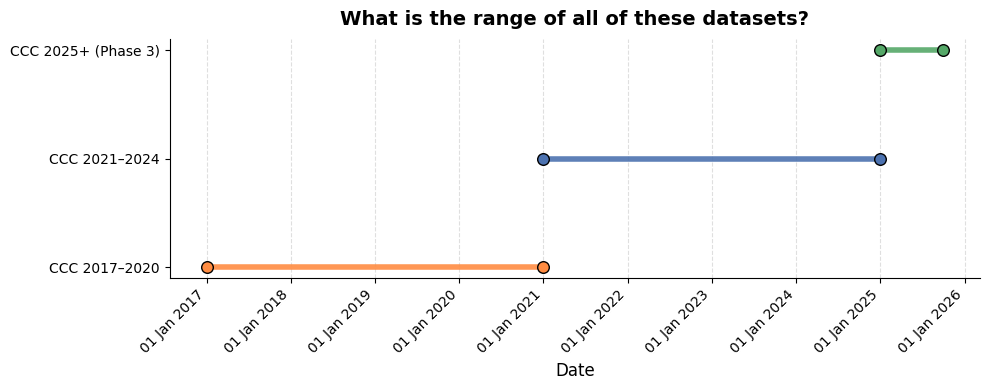

In [5]:
# --------------------------------------------------
# 1. Make sure `date` is datetime in all three
# --------------------------------------------------
for df in [ccc_2017_2020, ccc_2021_2024, ccc_2025_plus]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# --------------------------------------------------
# 2. Compute min/max date for each dataset
# --------------------------------------------------
datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

ranges = []
for label, df in datasets.items():
    valid_dates = df["date"].dropna()
    if len(valid_dates) == 0:
        start = pd.NaT
        end = pd.NaT
    else:
        start = valid_dates.min()
        end = valid_dates.max()
    ranges.append({"dataset": label, "start": start, "end": end})

ranges_df = pd.DataFrame(ranges)
ranges_df = ranges_df.dropna(subset=["start", "end"])
ranges_df = ranges_df.sort_values("start").reset_index(drop=True)

# Pretty display version with formatted dates
ranges_display = ranges_df.copy()
ranges_display["start"] = ranges_display["start"].dt.strftime("%d %b %Y")
ranges_display["end"]   = ranges_display["end"].dt.strftime("%d %b %Y")

print("Date ranges for each dataset:")
display(ranges_display)

# --------------------------------------------------
# 3. Barbell (dumbbell) plot of date ranges
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

y_positions = range(len(ranges_df))

# Different colors for each dataset (same style otherwise)
colors = ["#FF8C42", "#4C72B0", "#55A868"]  # orange, blue, green (or tweak if you like)

for i, (idx, row) in enumerate(ranges_df.iterrows()):
    color = colors[i % len(colors)]
    
    # Horizontal line: start -> end
    ax.hlines(
        y=idx,
        xmin=row["start"],
        xmax=row["end"],
        linewidth=4,
        color=color,
        alpha=0.9,
    )
    
    # Start and end points
    ax.scatter(row["start"], idx, s=70, color=color, edgecolor="black", zorder=3)
    ax.scatter(row["end"], idx, s=70, color=color, edgecolor="black", zorder=3)

# Y-axis labels = dataset names
ax.set_yticks(list(y_positions))
ax.set_yticklabels(ranges_df["dataset"])

# X-axis formatting: nice date labels like "12 Jan 2020"
ax.xaxis.set_major_locator(mdates.YearLocator())  # tick every year
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
plt.xticks(rotation=45, ha="right")

ax.set_title("What is the range of all of these datasets?", fontsize=14, fontweight="bold", pad=10)
ax.set_xlabel("Date", fontsize=12)

# Grid & style similar to your bar plot example
ax.grid(axis="x", linestyle="--", alpha=0.4)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

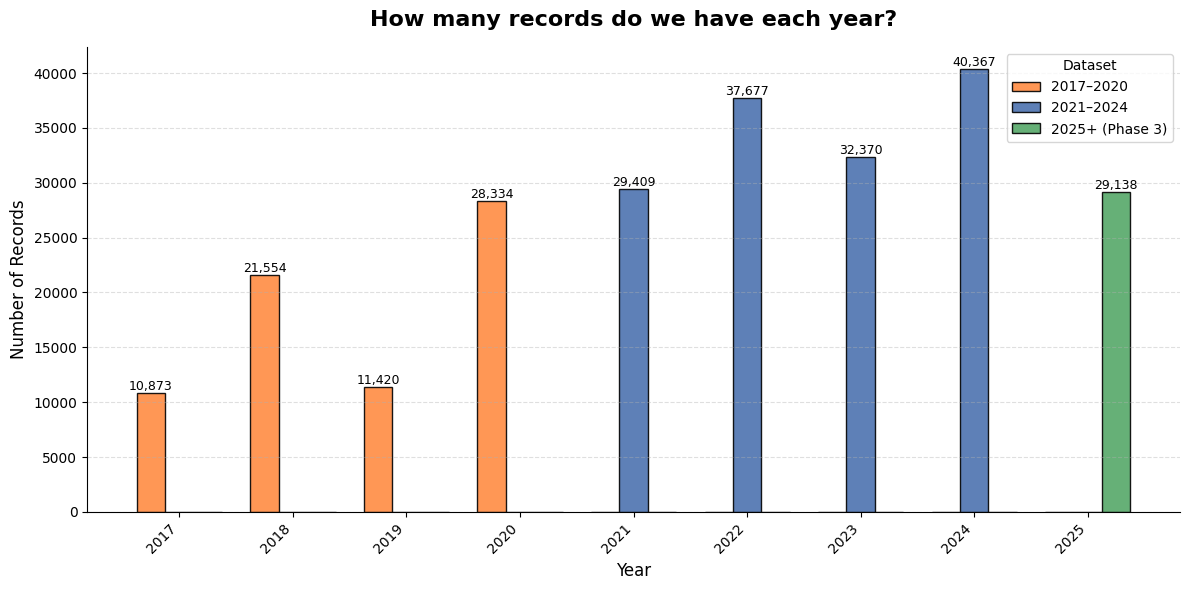

In [6]:
# 1. Make sure `date` is datetime in all three
for df in [ccc_2017_2020, ccc_2021_2024, ccc_2025_plus]:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 2. Counts per year for each dataset
counts_2017_2020 = (
    ccc_2017_2020["date"].dropna().dt.year.value_counts().sort_index()
)
counts_2021_2024 = (
    ccc_2021_2024["date"].dropna().dt.year.value_counts().sort_index()
)
counts_2025_plus = (
    ccc_2025_plus["date"].dropna().dt.year.value_counts().sort_index()
)

# 3. Combine into one DataFrame (outer join on years)
counts_df = pd.concat(
    [
        counts_2017_2020.rename("2017–2020"),
        counts_2021_2024.rename("2021–2024"),
        counts_2025_plus.rename("2025+ (Phase 3)"),
    ],
    axis=1,
).fillna(0).astype(int)

# 4. Grouped bar plot: one figure
years = counts_df.index.values
x = np.arange(len(years))  # positions for groups

bar_width = 0.25
colors = {
    "2017–2020": "#FF8C42",      # your original orange
    "2021–2024": "#4C72B0",      # blue
    "2025+ (Phase 3)": "#55A868" # green
}

plt.figure(figsize=(12, 6))

bars_by_label = {}

for i, col in enumerate(counts_df.columns):
    positions = x + (i - 1) * bar_width  # center around x
    bars = plt.bar(
        positions,
        counts_df[col].values,
        width=bar_width,
        label=col,
        color=colors[col],
        edgecolor="black",
        alpha=0.9,
    )
    bars_by_label[col] = bars

# Axes labels and title
plt.title("How many records do we have each year?", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)

# X-ticks in the center of groups
plt.xticks(x, years.astype(str), rotation=45, ha="right")

# Grid & style
plt.grid(axis="y", linestyle="--", alpha=0.4)
for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

# Bar labels
for col, bars in bars_by_label.items():
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{int(height):,}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

# What are the arrest and arrest any variables?

## Arrests variable across CCC datasets (Phases 1–3)

## Core idea (all three datasets)

- **Variable name:** `arrests`
- **Concept:** Number of **participants in the event who were arrested**.
- **Type:** Mixed — can be a **number** (`5`, `23`, …) or **text** (“more than 5”, “unspecified”, “dozens”).

So conceptually, all three phases are aiming to measure **the same thing**.

---

## Key differences in how it’s coded

1. **Conflicting sources**
   - Phase 1: Basic idea of “reported arrests,” but rules are less explicit.
   - Phase 2: Clear priority rules (police → organizers → highest reported).
   - Phase 3: Emphasizes coder judgment; use `unspecified` when you can’t pick a reliable number.

2. **No arrests vs unknown arrests**
   - Earlier phases: “No arrests” might appear as `0`, text (“none”), or just absence of mention.
   - Phase 3:
     - **No arrests:** leave `arrests` **blank**, rely on `arrests_any = 0`.
     - **Arrests occurred but number unclear:** set `arrests = "unspecified"`.

3. **Counter-protesters**
   - Phase 3 explicitly says: arrests of counter-protesters go in the **counter-protest’s row**.
   - If it’s unclear who was arrested, coders are told to use `unspecified`.
   - Earlier phases are less explicit about this distinction.

---

## Best solution

- We can treat `arrests` across phases as the **same construct**.
- We can also create:
  - A **binary** variable (e.g., `arrests_any`) that’s consistent across phases.
  - A cleaned **numeric** arrests variable (e.g., `arrests_n`), with clear rules for text/ambiguous values.


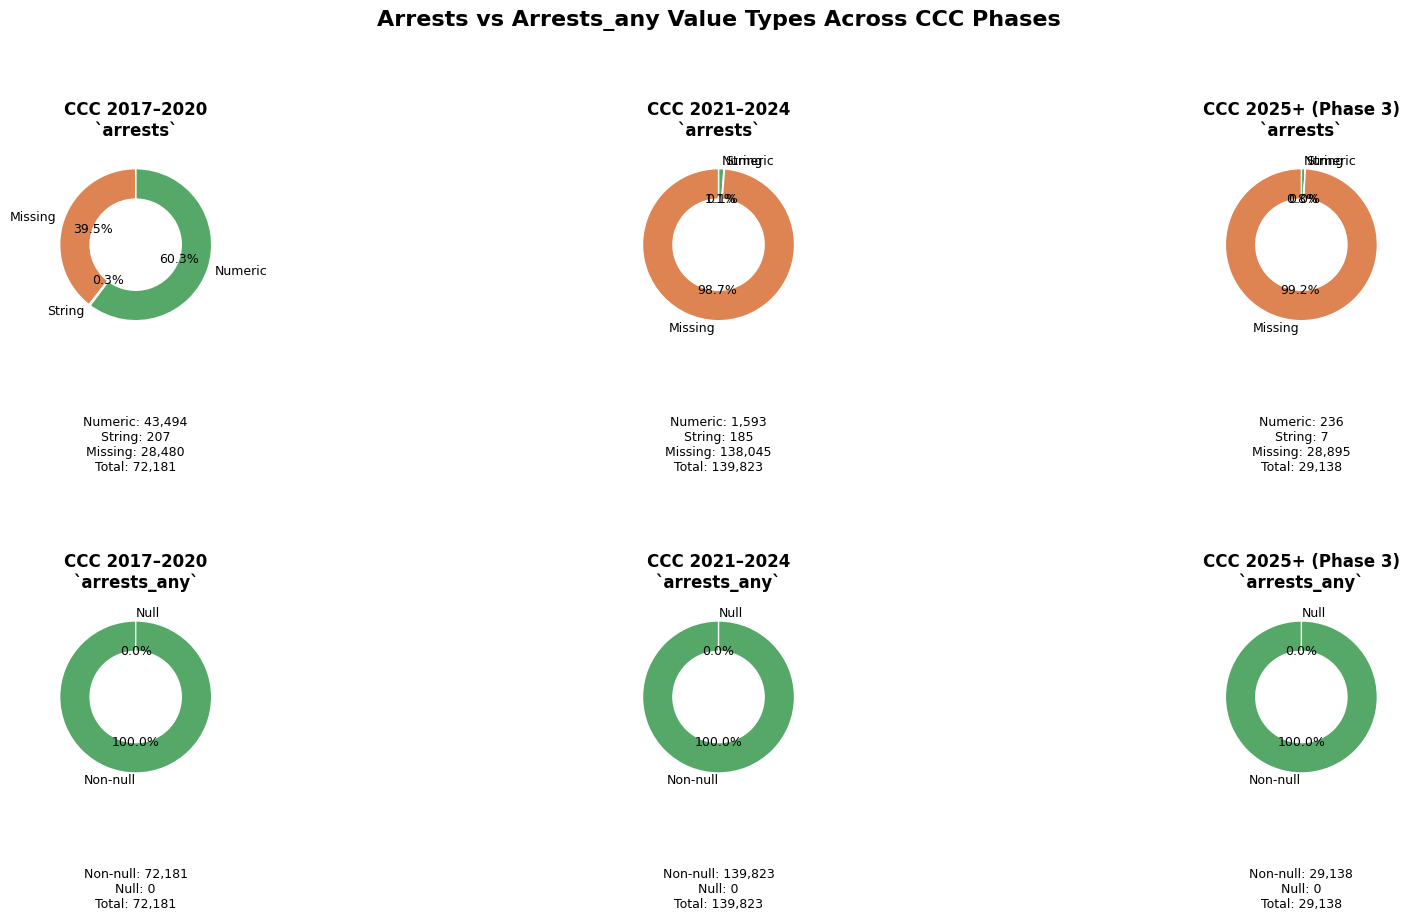

In [7]:
# ---------- Helpers ----------
def numeric_string_missing_counts(s: pd.Series):
    """Return counts of numeric, string, and missing values in a Series."""
    missing_count = s.isna().sum()
    s_nonnull = s.dropna()

    numeric_mask = pd.to_numeric(s_nonnull, errors="coerce").notna()
    numeric_count = numeric_mask.sum()
    string_count = (~numeric_mask).sum()

    return numeric_count, string_count, missing_count

def nonnull_null_counts(s: pd.Series):
    """Return counts of non-null and null values in a Series."""
    non_null = s.notna().sum()
    null = s.isna().sum()
    return non_null, null

# ---------- Datasets ----------
datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

# ---------- 1. Compute counts for arrests ----------
results_arrests = {}
for label, df in datasets.items():
    n_num, n_str, n_miss = numeric_string_missing_counts(df["arrests"])
    results_arrests[label] = {
        "numeric": n_num,
        "string": n_str,
        "missing": n_miss,
        "total": len(df),
    }

# ---------- 2. Compute counts for arrests_any ----------
results_any = {}
for label, df in datasets.items():
    non_null, null = nonnull_null_counts(df["arrests_any"])
    results_any[label] = {
        "non_null": non_null,
        "null": null,
        "total": len(df),
    }

# ---------- 3. Plot all donuts together (2 rows x 3 columns) ----------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Colors for arrests categories
arrests_category_colors = {
    "Numeric": "#55A868",   # green
    "String": "#4C72B0",    # blue
    "Missing": "#DD8452",   # orange/brown
}

# Colors for arrests_any categories
any_category_colors = {
    "Non-null": "#55A868",  # green
    "Null": "#DD8452",      # orange/brown
}

labels_list = list(datasets.keys())

for col_idx, label in enumerate(labels_list):
    # ---------- Top row: arrests (numeric / string / missing) ----------
    ax_top = axes[0, col_idx]
    counts = results_arrests[label]
    sizes = [counts["numeric"], counts["string"], counts["missing"]]
    labels_slices = ["Numeric", "String", "Missing"]
    colors = [arrests_category_colors[c] for c in labels_slices]

    ax_top.pie(
        sizes,
        labels=labels_slices,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.4, edgecolor="white"),  # donut
        textprops={"fontsize": 9},
    )
    ax_top.set_title(f"{label}\n`arrests`", fontsize=12, fontweight="bold", pad=10)
    ax_top.set_aspect("equal")

    # Text summary below the top donut
    text_top = (
        f"Numeric: {counts['numeric']:,}\n"
        f"String: {counts['string']:,}\n"
        f"Missing: {counts['missing']:,}\n"
        f"Total: {counts['total']:,}"
    )
    ax_top.text(
        0.5, -0.4, text_top,
        transform=ax_top.transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

    # ---------- Bottom row: arrests_any (non-null / null) ----------
    ax_bottom = axes[1, col_idx]
    counts_any = results_any[label]
    sizes_any = [counts_any["non_null"], counts_any["null"]]
    labels_slices_any = ["Non-null", "Null"]
    colors_any = [any_category_colors[c] for c in labels_slices_any]

    ax_bottom.pie(
        sizes_any,
        labels=labels_slices_any,
        colors=colors_any,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.4, edgecolor="white"),  # donut
        textprops={"fontsize": 9},
    )
    ax_bottom.set_title(f"{label}\n`arrests_any`", fontsize=12, fontweight="bold", pad=10)
    ax_bottom.set_aspect("equal")

    # Text summary below the bottom donut
    text_bottom = (
        f"Non-null: {counts_any['non_null']:,}\n"
        f"Null: {counts_any['null']:,}\n"
        f"Total: {counts_any['total']:,}"
    )
    ax_bottom.text(
        0.5, -0.4, text_bottom,
        transform=ax_bottom.transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

plt.suptitle(
    "Arrests vs Arrests_any Value Types Across CCC Phases",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

### We could assume that the missing values indicate that no arrest was made, but phase 2 has almost all missing values. Not sure if this makes sense.

### But the arrests_any column has no null values, this column seems reliable.

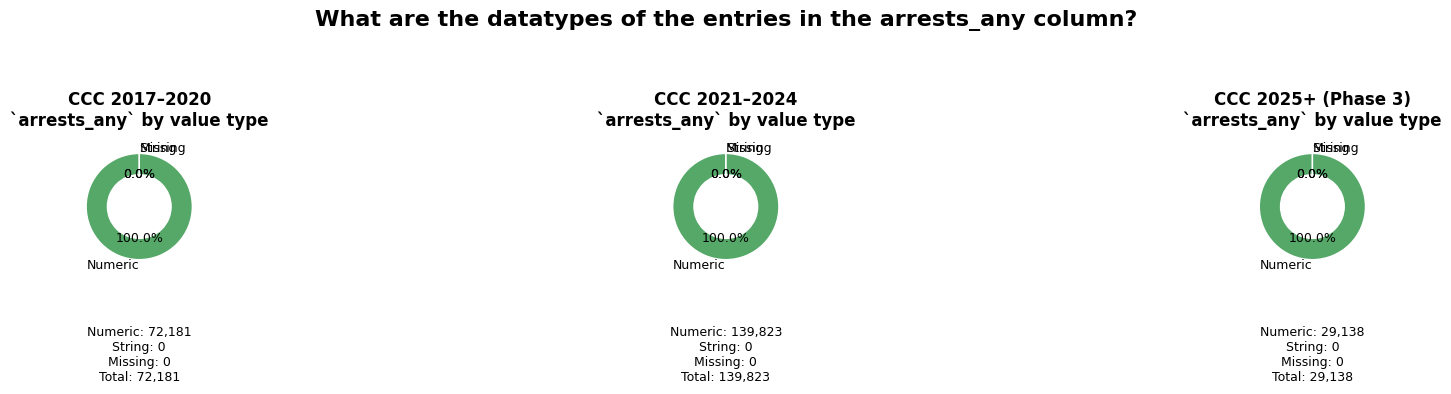

In [8]:
# ---------- Helper: numeric / string / missing ----------
def numeric_string_missing_counts(s: pd.Series):
    """Return counts of numeric, string, and missing values in a Series."""
    missing_count = s.isna().sum()
    s_nonnull = s.dropna()

    # Numeric if it can be coerced to a number
    numeric_mask = pd.to_numeric(s_nonnull, errors="coerce").notna()
    numeric_count = numeric_mask.sum()
    string_count = (~numeric_mask).sum()

    return numeric_count, string_count, missing_count

# ---------- Datasets ----------
datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

# ---------- Compute counts for arrests_any ----------
results_any_types = {}
for label, df in datasets.items():
    n_num, n_str, n_miss = numeric_string_missing_counts(df["arrests_any"])
    results_any_types[label] = {
        "numeric": n_num,
        "string": n_str,
        "missing": n_miss,
        "total": len(df),
    }

# ---------- Plot donuts (one row, 3 phases) ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Colors for categories
category_colors = {
    "Numeric": "#55A868",   # green
    "String": "#4C72B0",    # blue
    "Missing": "#DD8452",   # orange/brown
}

labels_list = list(datasets.keys())

for ax, label in zip(axes, labels_list):
    counts = results_any_types[label]
    sizes = [counts["numeric"], counts["string"], counts["missing"]]
    labels_slices = ["Numeric", "String", "Missing"]
    colors = [category_colors[c] for c in labels_slices]

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels_slices,
        colors=colors,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.4, edgecolor="white"),  # donut style
        textprops={"fontsize": 9},
    )

    ax.set_title(f"{label}\n`arrests_any` by value type", fontsize=12, fontweight="bold", pad=10)
    ax.set_aspect("equal")

    # Text summary under each donut
    text_summary = (
        f"Numeric: {counts['numeric']:,}\n"
        f"String: {counts['string']:,}\n"
        f"Missing: {counts['missing']:,}\n"
        f"Total: {counts['total']:,}"
    )
    ax.text(
        0.5, -0.4, text_summary,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=9,
    )

plt.suptitle(
    "What are the datatypes of the entries in the arrests_any column?",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

### It is entirely numeric

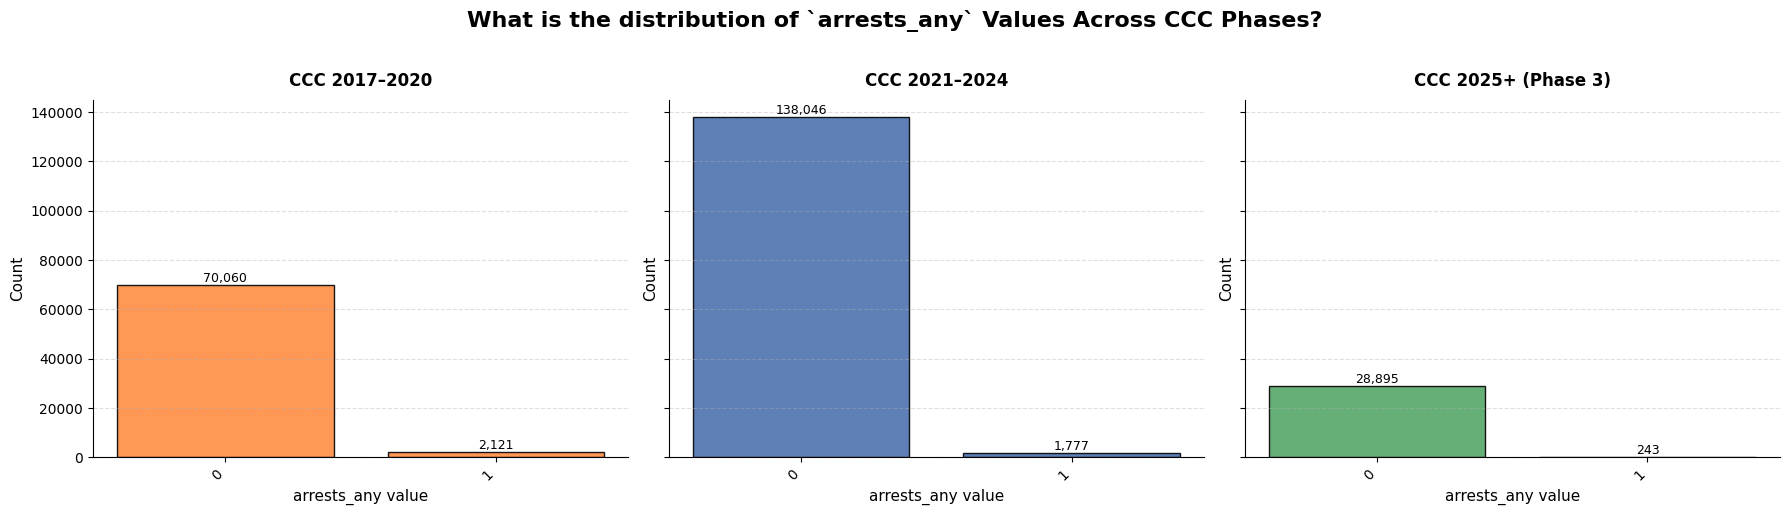

In [9]:
datasets = {
    "CCC 2017–2020": (ccc_2017_2020, "#FF8C42"),   # orange
    "CCC 2021–2024": (ccc_2021_2024, "#4C72B0"),   # blue
    "CCC 2025+ (Phase 3)": (ccc_2025_plus, "#55A868"),  # green
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

if len(datasets) == 1:
    axes = [axes]

for ax, (label, (df, color)) in zip(axes, datasets.items()):
    # Get value counts including missing
    ser = df["arrests_any"]
    counts = (
        ser.fillna("MISSING")      # show missing explicitly
           .astype(str)
           .value_counts()
           .sort_index()
    )

    x = range(len(counts))
    bars = ax.bar(
        x,
        counts.values,
        color=color,
        edgecolor="black",
        alpha=0.9,
    )

    ax.set_title(label, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("arrests_any value", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)

    ax.set_xticks(list(x))
    ax.set_xticklabels(counts.index.astype(str), rotation=45, ha="right")

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Add count labels on top of bars
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height,
                f"{int(height):,}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

plt.suptitle("What is the distribution of `arrests_any` Values Across CCC Phases?",
             fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### So all the missing values in the arrests column indicate that there have been no arrests made for that particular protest.

# What is the distrbution of the numerical part of the arrests variable?

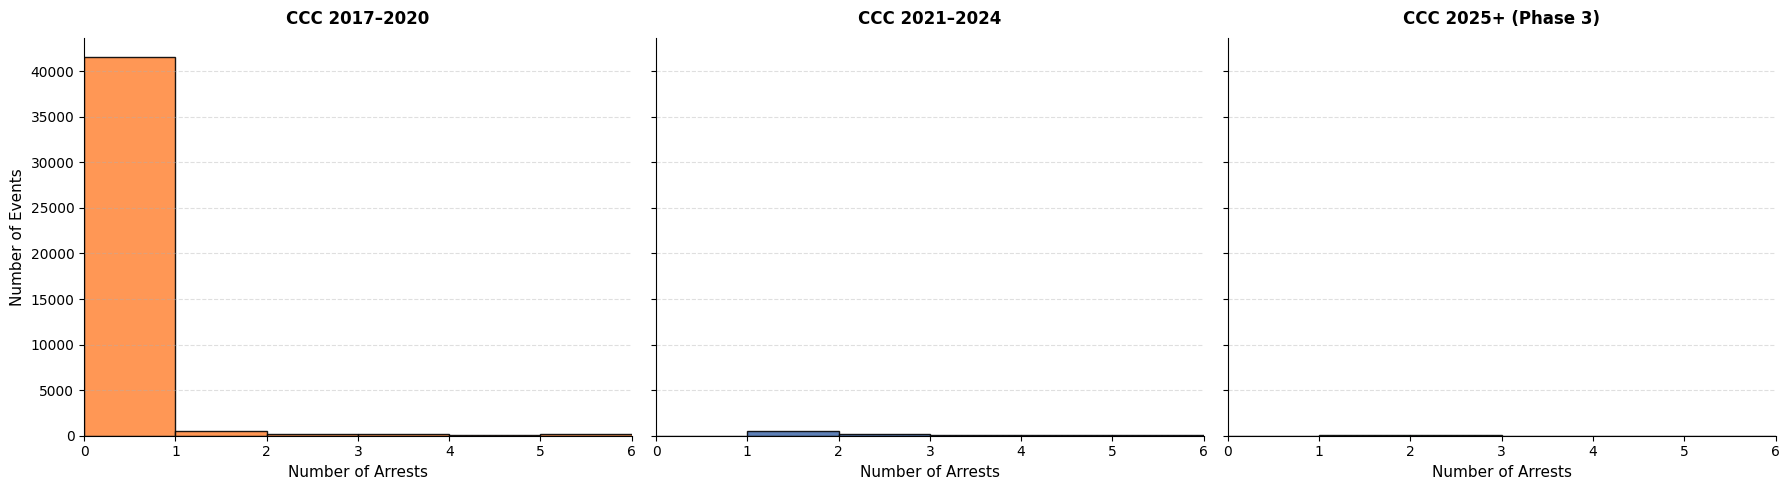

In [10]:
# Markdown heading at the top
display(Markdown("# What is the distrbution of the numerical part of the arrests variable?"))

# 1. Convert arrests to numeric, drop non-numeric values
arr_2017_2020 = pd.to_numeric(ccc_2017_2020["arrests"], errors="coerce").dropna()
arr_2021_2024 = pd.to_numeric(ccc_2021_2024["arrests"], errors="coerce").dropna()
arr_2025_plus = pd.to_numeric(ccc_2025_plus["arrests"], errors="coerce").dropna()

# 2. Decide a zoom range: use the 99th percentile across ALL phases
all_arrests = pd.concat([arr_2017_2020, arr_2021_2024, arr_2025_plus])
zoom_max = all_arrests.quantile(0.97)   # change to 0.95 or 0.90 if you want even tighter zoom
zoom_max_int = int(np.ceil(zoom_max))

# 3. Use 1-arrest-wide bins from 0 up to the zoom limit
bins = np.arange(0, zoom_max_int + 1)

# 4. Side-by-side histograms, all zoomed to the same x-range
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

datasets = [
    ("CCC 2017–2020", arr_2017_2020, "#FF8C42"),
    ("CCC 2021–2024", arr_2021_2024, "#4C72B0"),
    ("CCC 2025+ (Phase 3)", arr_2025_plus, "#55A868"),
]

for ax, (title, data, color) in zip(axes, datasets):
    # Only plot data within the zoom range (optional but keeps counts accurate in view)
    data_zoomed = data[data <= zoom_max_int]

    ax.hist(
        data_zoomed,
        bins=bins,
        color=color,
        edgecolor="black",
        alpha=0.9,
    )
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Number of Arrests", fontsize=11)
    ax.set_xlim(0, zoom_max_int)

    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel("Number of Events", fontsize=11)

plt.tight_layout()
plt.show()


### According to the guidelines, phases 2 and 3 started leaving arrests blank for 0 arrests, and in phase 1 we did not, we see a lot of zeros in phase 1

### Also, the no. of arrests are not higher than 3 for any protests 

In [11]:
display(Markdown("## What does the *string* part of the `arrests` variable look like?"))

def get_string_arrests(series: pd.Series) -> pd.Series:
    """
    Return only the non-missing, non-numeric values from an arrests Series.
    """
    s = series.copy()
    # Try numeric coercion; numeric values -> notna, strings -> NaN
    numeric_mask = pd.to_numeric(s, errors="coerce").notna()
    string_mask = s.notna() & ~numeric_mask
    return s[string_mask].astype(str).str.strip()

datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

string_values = {}

for label, df in datasets.items():
    s = get_string_arrests(df["arrests"])
    string_values[label] = s
    print(f"\n=== String arrests values in {label} ===")
    print(f"Total string values: {len(s):,}")
    display(
        s.value_counts()
         .head(20)
         .rename("count")
         .to_frame()
    )  # top 20 

## What does the *string* part of the `arrests` variable look like?


=== String arrests values in CCC 2017–2020 ===
Total string values: 207


,count
arrests,
unspecified,122
unclear,30
several,20
at least 1,3
more than a dozen,3
unknown,3
a few,3
4 (total pro and anti),2
see above,1



=== String arrests values in CCC 2021–2024 ===
Total string values: 185


,count
arrests,
unspecified,141
several,10
dozens,3
"3 total, unclear how many per group",2
at least 6,2
"6 in total, unclear how many per side",2
at least 4,2
at least 12,1
unpsecified,1



=== String arrests values in CCC 2025+ (Phase 3) ===
Total string values: 7


,count
arrests,
unspecified,4
at least 20,1
2; 13,1
40;86;10;20,1


## My conclusion is that we can drop the arrests variable and only rely on the arrest_any variable, as for most of the protests, the arrests are zero, and for the non-zero arrests, the number is not more than 3 for almost all of them again.

# Now we analyze the fips code variable

## What is a FIPS code?

**FIPS** stands for **Federal Information Processing Standards**.  
In the CCC datasets, the `fips_code` column refers to the **5-digit FIPS county code**, which:

- Uniquely identifies **counties and county-equivalent units** in the United States  
  - The first **2 digits** = state code  
  - The last **3 digits** = county code within that state  
- Covers counties, parishes (Louisiana), boroughs/census areas (Alaska), and county-equivalents in U.S. territories.
- Is typically represented as a **zero-padded string**, e.g.:
  - `"06037"` = Los Angeles County, California  
  - `"36061"` = New York County (Manhattan), New York  

In the CCC data, `fips_code` is used to record the **county where the event took place**, when that location is within the U.S. or its territories. Rows for events outside these areas will have `fips_code` missing.


In [12]:
display(Markdown("## How many null values are in the `fips_code` column?"))

datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

for name, df in datasets.items():
    total = len(df)
    nulls = df["fips_code"].isna().sum()
    non_nulls = total - nulls
    pct_null = (nulls / total) * 100 if total > 0 else 0

    print(f"\n{name}")
    print(f"  Total rows       : {total:,}")
    print(f"  Non-null fips    : {non_nulls:,}")
    print(f"  Null fips        : {nulls:,} ({pct_null:5.2f}%)")

## How many null values are in the `fips_code` column?


CCC 2017–2020
  Total rows       : 72,181
  Non-null fips    : 72,074
  Null fips        : 107 ( 0.15%)

CCC 2021–2024
  Total rows       : 139,823
  Non-null fips    : 139,697
  Null fips        : 126 ( 0.09%)

CCC 2025+ (Phase 3)
  Total rows       : 29,138
  Non-null fips    : 29,028
  Null fips        : 110 ( 0.38%)


## Where are CCC events located (dot size & color = number of events per FIPS)?

/tmp/ipykernel_17240/842036213.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centers = gdf.geometry.centroid
/tmp/ipykernel_17240/842036213.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centers = gdf.geometry.centroid
/tmp/ipykernel_17240/842036213.py:36: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centers = gdf.geometry.centroid


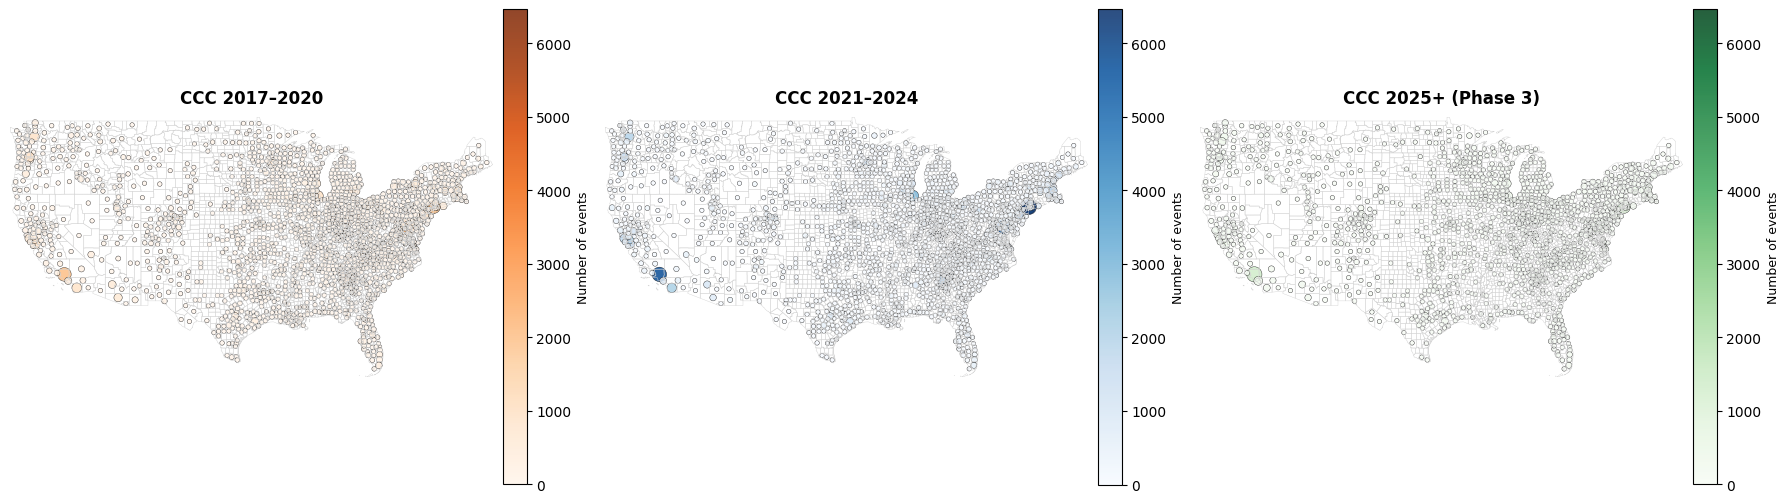

In [13]:
display(Markdown("## Where are CCC events located (dot size & color = number of events per FIPS)?"))

# ---------- 1. Clean FIPS as 5-digit strings ----------
def clean_fips(df, col="fips_code"):
    s = pd.to_numeric(df[col], errors="coerce")
    fips_clean = s.round().astype("Int64")       # nullable int
    fips_str = fips_clean.astype(str).str.zfill(5)
    fips_str[s.isna()] = pd.NA                   # restore NaNs
    df["fips_code_clean"] = fips_str

for df in [ccc_2017_2020, ccc_2021_2024, ccc_2025_plus]:
    clean_fips(df)

# ---------- 2. Load county shapes & keep contiguous U.S. ----------
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_5m.zip"
)
counties["GEOID"] = counties["STATEFP"] + counties["COUNTYFP"]

exclude_states = ["02", "15", "60", "66", "69", "72", "78"]  # AK, HI, territories
counties_conus = counties[~counties["STATEFP"].isin(exclude_states)].copy()

minx, miny, maxx, maxy = counties_conus.total_bounds

# ---------- 3. Build centroids + counts per FIPS ----------
def fips_centroids_with_counts(df):
    counts = (
        df["fips_code_clean"]
        .dropna()
        .value_counts()
        .rename("count")
        .rename_axis("GEOID")
        .reset_index()
    )
    gdf = counties_conus.merge(counts, on="GEOID", how="inner")  # only FIPS with events
    centers = gdf.geometry.centroid
    gdf["x"] = centers.x
    gdf["y"] = centers.y
    return gdf

gdf_17_20 = fips_centroids_with_counts(ccc_2017_2020)
gdf_21_24 = fips_centroids_with_counts(ccc_2021_2024)
gdf_25p   = fips_centroids_with_counts(ccc_2025_plus)

# ---------- 4. Scale dot sizes by count ----------
def scale_sizes(counts, min_size=10, max_size=120):
    counts = counts.astype(float)
    if counts.max() == counts.min():
        return np.full_like(counts, (min_size + max_size) / 2.0)
    return min_size + (counts - counts.min()) / (counts.max() - counts.min()) * (max_size - min_size)

# Shared color scale across all phases so colors are comparable
global_max = max(
    gdf_17_20["count"].max(),
    gdf_21_24["count"].max(),
    gdf_25p["count"].max(),
)

# ---------- 5. Plot three dot maps side by side (size + color = count) ----------
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

maps = [
    ("CCC 2017–2020", gdf_17_20, "Oranges"),
    ("CCC 2021–2024", gdf_21_24, "Blues"),
    ("CCC 2025+ (Phase 3)", gdf_25p, "Greens"),
]

for ax, (title, gdf, cmap_name) in zip(axes, maps):
    # background county outlines
    counties_conus.boundary.plot(ax=ax, linewidth=0.3, color="lightgray")

    sizes = scale_sizes(gdf["count"])
    sc = ax.scatter(
        gdf["x"],
        gdf["y"],
        s=sizes,
        c=gdf["count"],
        cmap=cmap_name,
        vmin=0,
        vmax=global_max,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.3,
    )

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.axis("off")

    # colorbar for each map
    cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("Number of events", fontsize=9)

plt.tight_layout()
plt.show()

### The midwest doesn't have much protests, the east and west coasts do thought, especially LA and NY.

# Do the latitude and longitude columns show similar results?

## Where are CCC events located (by latitude & longitude)?

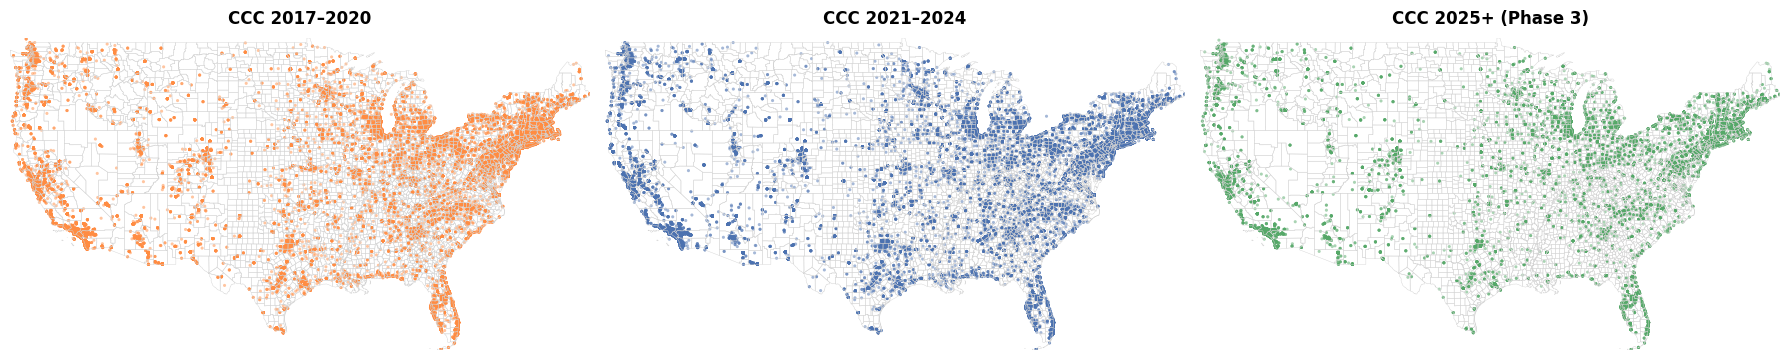

In [14]:
display(Markdown("## Where are CCC events located (by latitude & longitude)?"))

# 1. Load US county shapes and keep contiguous U.S. for background
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_5m.zip"
)
counties["GEOID"] = counties["STATEFP"] + counties["COUNTYFP"]

exclude_states = ["02", "15", "60", "66", "69", "72", "78"]  # AK, HI, territories
counties_conus = counties[~counties["STATEFP"].isin(exclude_states)].copy()

minx, miny, maxx, maxy = counties_conus.total_bounds

# 2. Helper: get clean lat/lon for each dataset (numeric, in reasonable US bounds)
def get_clean_lat_lon(df):
    lat = pd.to_numeric(df["lat"], errors="coerce")
    lon = pd.to_numeric(df["lon"], errors="coerce")

    # Rough bounding box for US (adjust if needed)
    mask = (
        lat.between(18, 72) &
        lon.between(-180, -60)
    )

    lat_clean = lat[mask]
    lon_clean = lon[mask]
    return lat_clean, lon_clean

latlon_17_20 = get_clean_lat_lon(ccc_2017_2020)
latlon_21_24 = get_clean_lat_lon(ccc_2021_2024)
latlon_25p   = get_clean_lat_lon(ccc_2025_plus)

# 3. Plot side-by-side scatter maps of lat/lon
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharex=True, sharey=True)

datasets = [
    ("CCC 2017–2020", latlon_17_20, "#FF8C42"),
    ("CCC 2021–2024", latlon_21_24, "#4C72B0"),
    ("CCC 2025+ (Phase 3)", latlon_25p, "#55A868"),
]

for ax, (title, (lat, lon), color) in zip(axes, datasets):
    # Background map
    counties_conus.boundary.plot(ax=ax, linewidth=0.3, color="lightgray")

    # Event points
    ax.scatter(
        lon,
        lat,
        s=5,
        alpha=0.5,
        color=color,
        edgecolor="none",
    )

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Yes they do!

# What is the locality variable?

## What is the `locality` column?

Across all three CCC phases, **`locality`** records the *name of the place (city/town)* where the event happened.

- **Core definition (all phases)**  
  - Name of the **city, town, or township** in which the event occurred.  
  - Used as the main human-readable place name for the event.

- **Phase-specific notes from the guidelines**
  - **Phase 1 (2017–2020):**  
    - “Name of the locality in which the event took place” (called *CityTown* in the original sheets).
  - **Phase 2 (2021–2024):**  
    - “Name of the locality (i.e., city or town) in which the event took place.”  
    - If only a **county** is given, the **county seat** is used as the locality.  
    - Online events can still get a locality if organizers name one.
  - **Phase 3 (2025+):**  
    - “Record the name of the city, town, or township in which the event occurred.”  
    - If an event spans multiple towns, coders pick **one notable locality** (often the start or end) for `locality` and list the others in `location`.

In analysis, we can treat `locality` as the **primary city/town label** for where the event is located.


## Which localities have the most CCC events?

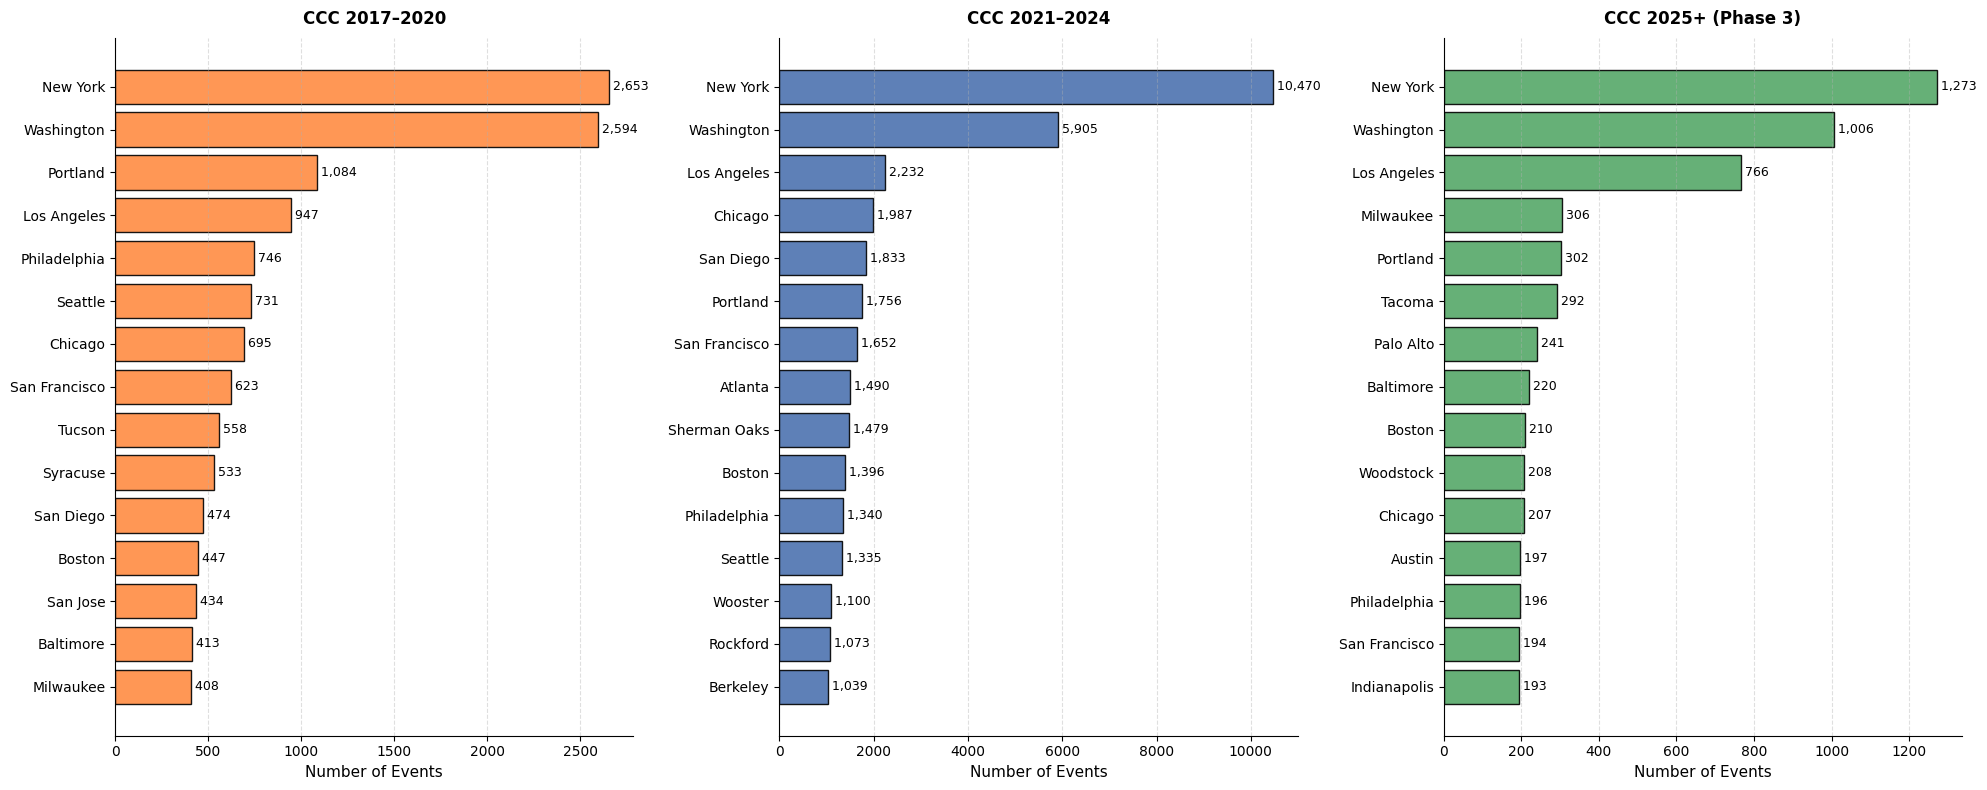

In [15]:
display(Markdown("## Which localities have the most CCC events?"))

datasets = {
    "CCC 2017–2020": (ccc_2017_2020, "#FF8C42"),
    "CCC 2021–2024": (ccc_2021_2024, "#4C72B0"),
    "CCC 2025+ (Phase 3)": (ccc_2025_plus, "#55A868"),
}

top_n = 15

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=False)

for ax, (label, (df, color)) in zip(axes, datasets.items()):
    # Get clean locality (string, drop missing)
    loc = df["locality"].dropna().astype(str).str.strip()

    # Count and keep top N
    counts = loc.value_counts().head(top_n).sort_values(ascending=True)

    ax.barh(
        counts.index,
        counts.values,
        color=color,
        edgecolor="black",
        alpha=0.9,
    )

    ax.set_title(label, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Number of Events", fontsize=11)
    ax.grid(axis="x", linestyle="--", alpha=0.4)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Add counts at the end of bars
    for i, v in enumerate(counts.values):
        ax.text(
            v,
            i,
            f" {int(v):,}",
            va="center",
            ha="left",
            fontsize=9,
        )

plt.tight_layout()
plt.show()

## What is the `resolved_locality` variable?

`resolved_locality` is the **cleaned, standardized version of the locality name** for an event.

In the CCC data:

- `locality` is the **original city/town name** as coded by humans (can include spelling differences, abbreviations, etc.).
- `resolved_locality` is the **normalized place name** after running the event’s location through a geocoder (together with `resolved_state`).

You can think of `resolved_locality` as:

> “The standardized city/town name for where this event occurred, suitable for analysis and matching across datasets.”

It pairs with:
- `resolved_state` → standardized state name/abbreviation  
- `resolved_county` → standardized county name  
- `fips_code` → numeric county identifier


## What is the `resolved_state` variable?

`resolved_state` is the **cleaned, standardized state for the event’s location**.

In the CCC data:

- Coders record the state in the original `state` column (which can include variations like full names, abbreviations, or occasional inconsistencies).
- `resolved_state` is the **normalized state** returned by the geocoding process, consistent across events.

You can think of `resolved_state` as:

> “The standardized state associated with this event’s location.”

It’s designed to work together with:

- `resolved_locality` → standardized city/town  
- `resolved_county` → standardized county  
- `fips_code` → 5-digit numeric county identifier


## What is the `resolved_county` variable?

`resolved_county` is the **standardized name of the county where the event took place**.

Behind the scenes:

- CCC starts from the event’s **resolved locality** (`resolved_locality`) and **resolved state** (`resolved_state`).
- Those are sent to a geocoding service (Google Maps / similar).
- The service returns a **clean, standardized county name**, which is stored in `resolved_county`.

In practice, you can think of `resolved_county` as:

> “The cleaned county name for this event, derived from its locality and state.”

It’s the human-readable counterpart to `fips_code` (which is the numeric county identifier).


## Hierarchical drilldown: Phase → State → County → Locality

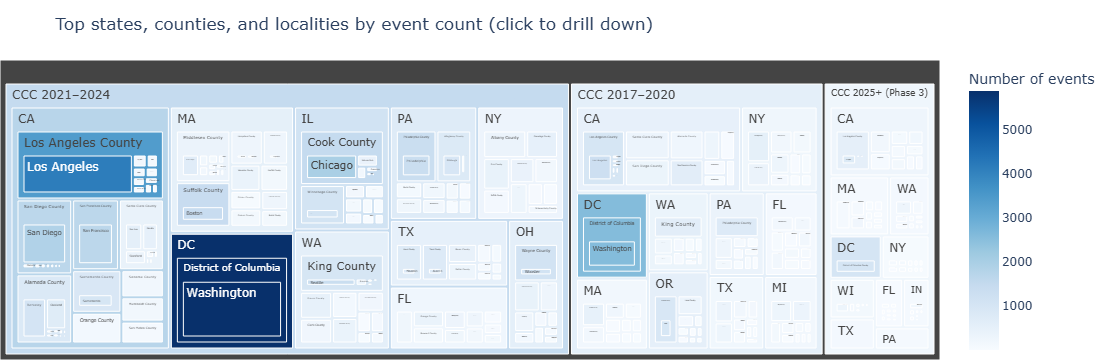

In [16]:
display(Markdown("## Hierarchical drilldown: Phase → State → County → Locality"))

# ---------------- Config ----------------
TOP_STATES = 10
TOP_COUNTIES = 10
TOP_LOCALITIES = 10

# ---------------- 1. Combine all 3 phases into one DataFrame ----------------
df_17_20 = ccc_2017_2020.copy()
df_21_24 = ccc_2021_2024.copy()
df_25p   = ccc_2025_plus.copy()

df_17_20["phase"] = "CCC 2017–2020"
df_21_24["phase"] = "CCC 2021–2024"
df_25p["phase"]   = "CCC 2025+ (Phase 3)"

df_all = pd.concat([df_17_20, df_21_24, df_25p], ignore_index=True)

# Clean resolved columns
for col in ["resolved_state", "resolved_county", "resolved_locality"]:
    df_all[col] = df_all[col].astype("string").str.strip()

# ---------------- 2. Aggregate at (phase, state, county, locality) level ----------------
df_loc = (
    df_all
    .dropna(subset=["resolved_state", "resolved_county", "resolved_locality"])
    .groupby(["phase", "resolved_state", "resolved_county", "resolved_locality"])
    .size()
    .reset_index(name="count")
)

# ---------------- 3. Compute ranks to enforce Top 10 / Top 10 / Top 10 ----------------

# State totals & rank per phase
state_totals = (
    df_loc
    .groupby(["phase", "resolved_state"])["count"]
    .sum()
    .reset_index(name="state_count")
)
state_totals["state_rank"] = (
    state_totals
    .groupby("phase")["state_count"]
    .rank(method="first", ascending=False)
)

# County totals & rank within (phase, state)
county_totals = (
    df_loc
    .groupby(["phase", "resolved_state", "resolved_county"])["count"]
    .sum()
    .reset_index(name="county_count")
)
county_totals["county_rank"] = (
    county_totals
    .groupby(["phase", "resolved_state"])["county_count"]
    .rank(method="first", ascending=False)
)

# Locality totals & rank within (phase, state, county)
loc_totals = df_loc.copy()
loc_totals["locality_rank"] = (
    loc_totals
    .groupby(["phase", "resolved_state", "resolved_county"])["count"]
    .rank(method="first", ascending=False)
)

# ---------------- 4. Merge ranks back into df_loc ----------------
df_ranked = (
    df_loc
    .merge(state_totals[["phase", "resolved_state", "state_rank"]], 
           on=["phase", "resolved_state"], how="left")
    .merge(county_totals[["phase", "resolved_state", "resolved_county", "county_rank"]],
           on=["phase", "resolved_state", "resolved_county"], how="left")
    .merge(loc_totals[["phase", "resolved_state", "resolved_county", "resolved_locality", "locality_rank"]],
           on=["phase", "resolved_state", "resolved_county", "resolved_locality"], how="left")
)

# ---------------- 5. Filter to top 10 / top 10 / top 10 ----------------
df_filtered = df_ranked[
    (df_ranked["state_rank"] <= TOP_STATES) &
    (df_ranked["county_rank"] <= TOP_COUNTIES) &
    (df_ranked["locality_rank"] <= TOP_LOCALITIES)
].copy()

# ---------------- 6. Build interactive treemap ----------------
# Path gives the drill-down hierarchy. Clicking lets you zoom:
# phase → state → county → locality
fig = px.treemap(
    df_filtered,
    path=["phase", "resolved_state", "resolved_county", "resolved_locality"],
    values="count",
    color="count",
    color_continuous_scale="Blues",
    title="Top states, counties, and localities by event count (click to drill down)"
)

fig.update_layout(
    margin=dict(t=60, l=0, r=0, b=0),
    coloraxis_colorbar=dict(title="Number of events")
)

fig.show()

## What is the `state` variable?

`state` records the **U.S. state or territory where the event took place**, as originally coded by the CCC team.

Key points:

- It is usually stored as a **two-letter USPS abbreviation** (e.g., `CA`, `TX`, `NY`), though early coding may sometimes include minor inconsistencies.
- It reflects the **coder’s original entry**, based on the event location in the sources.
- It is the **input** for later, cleaned location fields:
  - `resolved_state` (standardized state)
  - `resolved_county`
  - `resolved_locality`
  - `fips_code`

In practice:

> Use `state` when you want the **raw coded state**, and `resolved_state` when you want the **clean, standardized** version suitable for analysis and joining across datasets.


## What is the `macroevent` variable?

`macroevent` is an **ID that links together all events that are part of the same protest–counter-protest cluster**.

- Each `macroevent` value groups:
  - The **main protest**, and  
  - Any **counter-protests** (and sometimes community-defense actions) that are responding to it.

All rows that belong to the same cluster share the **same `macroevent` ID**.

The ID is usually built from:
1. The **date** of the main protest (e.g., `20220624`),  
2. A short **location** string (e.g., `phoenix`),  
3. A brief **issue/topic** label (e.g., `abortion`),

combined like:

> `20220624-phoenix-abortion`

If `macroevent` is missing, that event is not currently linked into a protest–counter-protest cluster via this system.


In [17]:
display(Markdown("## How many unique `macroevent` IDs are there in each phase?"))

datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

unique_counts = {}

for name, df in datasets.items():
    # count distinct non-missing macroevent IDs
    n_unique = df["macroevent"].dropna().nunique()
    unique_counts[name] = n_unique
    print(f"{name}: {n_unique:,} unique macroevents")

# overall across all phases
all_macroevents = pd.concat(
    [df["macroevent"] for df in datasets.values()],
    ignore_index=True,
)

total_unique = all_macroevents.dropna().nunique()
print(f"\nTotal unique macroevents across ALL phases: {total_unique:,}")

## How many unique `macroevent` IDs are there in each phase?

CCC 2017–2020: 928 unique macroevents
CCC 2021–2024: 3,722 unique macroevents
CCC 2025+ (Phase 3): 416 unique macroevents

Total unique macroevents across ALL phases: 5,066


In [18]:
display(Markdown("## How many events have no `macroevent` ID?"))

datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

for name, df in datasets.items():
    total = len(df)
    
    # Treat NaN or empty/whitespace-only strings as "no macroevent"
    macro = df["macroevent"].astype("string")
    has_macro = macro.notna() & (macro.str.strip() != "")
    
    n_with = has_macro.sum()
    n_without = total - n_with
    pct_without = (n_without / total * 100) if total > 0 else 0.0

    print(f"\n{name}")
    print(f"  Total events           : {total:,}")
    print(f"  With macroevent ID     : {n_with:,}")
    print(f"  Without macroevent ID  : {n_without:,} ({pct_without:5.2f}%)")

## How many events have no `macroevent` ID?


CCC 2017–2020
  Total events           : 72,181
  With macroevent ID     : 1,879
  Without macroevent ID  : 70,302 (97.40%)

CCC 2021–2024
  Total events           : 139,823
  With macroevent ID     : 7,700
  Without macroevent ID  : 132,123 (94.49%)

CCC 2025+ (Phase 3)
  Total events           : 29,138
  With macroevent ID     : 831
  Without macroevent ID  : 28,307 (97.15%)


In [19]:
display(Markdown("## Top 10 macroevents by number of linked events (per phase)"))

datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

for phase_name, df in datasets.items():
    display(Markdown(f"### {phase_name}"))

    # Clean macroevent (treat NaN / empty as missing)
    macro = df["macroevent"].astype("string").str.strip()
    mask_valid = macro.notna() & (macro != "")

    macro_valid = macro[mask_valid]

    # Group by macroevent and count number of rows (events) linked to each
    macro_stats = (
        macro_valid
        .value_counts()
        .rename_axis("macroevent")
        .reset_index(name="n_events")
        .sort_values("n_events", ascending=False)
        .head(10)
    )

    display(macro_stats)

## Top 10 macroevents by number of linked events (per phase)

### CCC 2017–2020

,macroevent,n_events
0,20201212-dc-trump,6
2,20201012-dc-scotus,5
1,20200918-bemidji-trump,5
4,20201013-dc-scotus,4
3,20200926-pdx-proudboys,4
6,20200607-spokane-blm,3
5,20200623-philly-blm,3
8,20201114-dc-millionmagamarch,3
9,20201101-queens-trump,3
7,20200707-smithtown-blm,3


### CCC 2021–2024

,macroevent,n_events
0,20230310-denton-prayerrally,8
1,20240819-chicago-marchonthednc,7
2,20221217-grandprairie-dragshow,6
3,20241027-nyc-trumpatmsg,6
4,20240420-yale-palestine,5
5,20230120-dc-marchforlife,5
6,20240122-bigbend-harris,5
7,20221203-columbus-dragshow,5
9,20240724-dccapitol-netanyahu,5
8,20220503-dc-roevwade,5


### CCC 2025+ (Phase 3)

,macroevent,n_events
0,20250118-dc-peoplesmarch,4
1,20250614-idahofalls-nokings,3
2,20250802-concord-rageagainsttheregime,3
3,20250125-dc-marchforlife,3
4,20250125-sf-marchforlife,3
281,20250229-nyczuccotti-hindrajab,2
282,20250222-providence-doge,2
283,20250222-Pottsville-Trump,2
280,20250125-peterborough-racialjustice,2
285,20250218-nyc-palestine,2


## What is the `online` variable?

`online` is a **binary indicator for online-only events**.

Across the CCC phases, it is defined as:

- **Type:** 0/1 (binary)
- **Meaning:**
  - `1` = the event is **online-only / virtual**  
  - `0` = the event is **in-person** (even if it also has livestreams or online promotion)
- **How it’s created:**  
  - Generated from the event’s **location** and **event_type** information in the source data  
    (e.g., presence of terms like “virtual”, “online”, and an “online” location).

In short:

> Use `online = 1` to identify **purely virtual events** (webinars, online rallies, livestream-only protests, etc.), and `online = 0` for events where people gather **physically in a place**.


## Online vs in-person events (`online` variable)

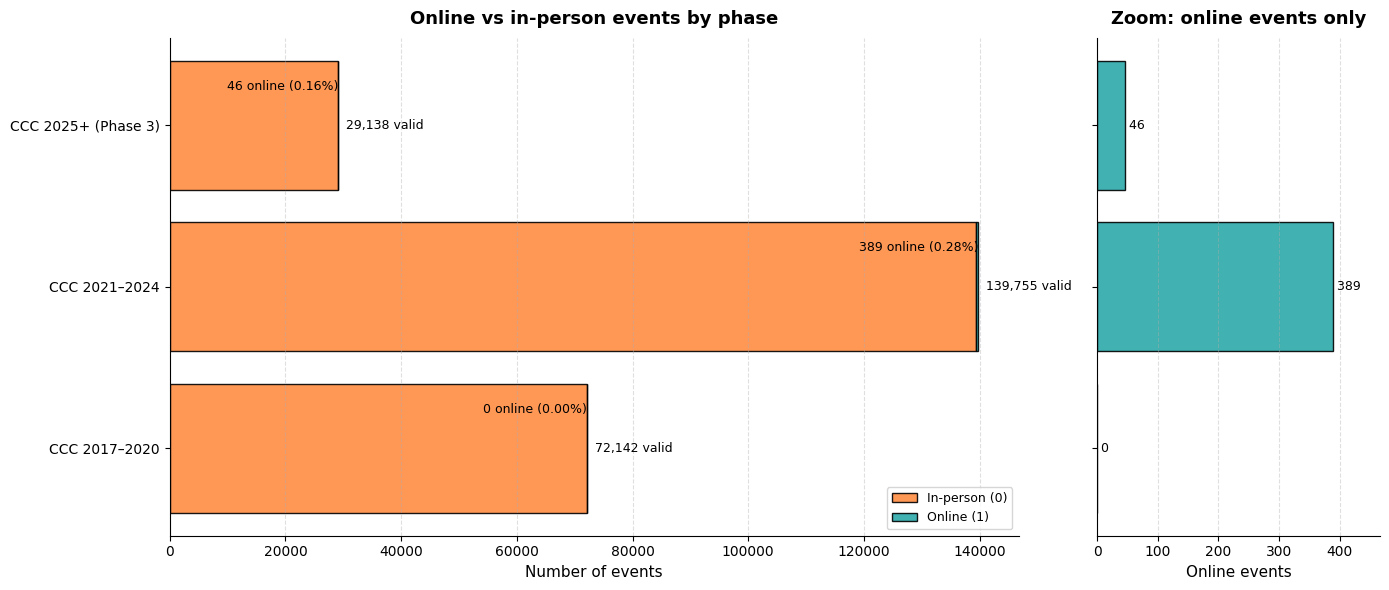

CCC 2017–2020: 39 rows with missing/other `online` value
CCC 2021–2024: 68 rows with missing/other `online` value
CCC 2025+ (Phase 3): 0 rows with missing/other `online` value


In [20]:
display(Markdown("## Online vs in-person events (`online` variable)"))

def online_counts(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce")
    total = len(s)

    n_online = (s == 1).sum()
    n_offline = (s == 0).sum()
    n_valid = n_online + n_offline
    n_missing = total - n_valid

    return n_online, n_offline, n_missing, total

datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

phase_names = list(datasets.keys())

online_vals = []
offline_vals = []
missing_vals = []
totals = []

for name, df in datasets.items():
    n_online, n_offline, n_missing, total = online_counts(df["online"])
    online_vals.append(n_online)
    offline_vals.append(n_offline)
    missing_vals.append(n_missing)
    totals.append(total)

# --- Figure with two panels: full + zoomed online ---
fig, (ax_full, ax_zoom) = plt.subplots(
    1, 2, figsize=(14, 6), gridspec_kw={"width_ratios": [3, 1]}
)

y_pos = range(len(phase_names))

colors = {
    "offline": "#FF8C42",   # orange
    "online": "#2CA9A9",    # teal
}

# ===== LEFT: full stacked bars =====
bars_offline = ax_full.barh(
    y_pos,
    offline_vals,
    color=colors["offline"],
    edgecolor="black",
    alpha=0.9,
    label="In-person (0)",
)

bars_online = ax_full.barh(
    y_pos,
    online_vals,
    left=offline_vals,
    color=colors["online"],
    edgecolor="black",
    alpha=0.9,
    label="Online (1)",
)

ax_full.set_yticks(list(y_pos))
ax_full.set_yticklabels(phase_names)
ax_full.set_xlabel("Number of events", fontsize=11)
ax_full.set_title("Online vs in-person events by phase", fontsize=13, fontweight="bold", pad=10)

ax_full.grid(axis="x", linestyle="--", alpha=0.4)
for spine in ["top", "right"]:
    ax_full.spines[spine].set_visible(False)

# Labels on full bars
for i, (offline, online, total) in enumerate(zip(offline_vals, online_vals, totals)):
    total_valid = offline + online
    pct_online = (online / total_valid * 100) if total_valid > 0 else 0.0

    ax_full.text(
        offline + online,
        i,
        f"  {offline + online:,} valid",
        va="center",
        ha="left",
        fontsize=9,
    )

    ax_full.text(
        offline + online,
        i + 0.2,
        f"{online:,} online ({pct_online:.2f}%)",
        va="bottom",
        ha="right",
        fontsize=9,
        color="black",
    )

ax_full.legend(loc="lower right", fontsize=9)

# ===== RIGHT: zoomed-in view (online only) =====
max_online = max(online_vals) if online_vals else 1

bars_zoom = ax_zoom.barh(
    y_pos,
    online_vals,
    color=colors["online"],
    edgecolor="black",
    alpha=0.9,
)

ax_zoom.set_yticks(list(y_pos))
ax_zoom.set_yticklabels([])  # hide labels here, use left panel's y-axis labels
ax_zoom.set_xlabel("Online events", fontsize=11)
ax_zoom.set_title("Zoom: online events only", fontsize=13, fontweight="bold", pad=10)

ax_zoom.set_xlim(0, max_online * 1.2)

ax_zoom.grid(axis="x", linestyle="--", alpha=0.4)
for spine in ["top", "right"]:
    ax_zoom.spines[spine].set_visible(False)

# Labels on zoomed bars
for i, online in enumerate(online_vals):
    ax_zoom.text(
        online,
        i,
        f" {online:,}",
        va="center",
        ha="left",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# Optional: quick text summary of missing
for name, miss in zip(phase_names, missing_vals):
    print(f"{name}: {miss:,} rows with missing/other `online` value")

## What is the `notes` variable?

`notes` is a **free-text field** where coders record extra information about an event that doesn’t fit neatly into the structured columns.

Typical uses include:

- Clarifying **coding decisions** (e.g., why a particular size, arrests count, or issue tag was chosen).  
- Flagging **uncertainty or ambiguity** in sources (“conflicting reports on arrests”, “location unclear between X and Y”).  
- Recording **unusual circumstances** (e.g., multiple actions merged into one row, overlapping protests and counter-protests).  
- Adding brief **context** that may be useful for future review or qualitative analysis.

In practice, you should treat `notes` as:

> A **human-written comment field** for documentation and context, not as a systematically coded variable for quantitative analysis.


## How is the `notes` variable used?

### CCC 2017–2020

Rows with notes   : 17,526 (24.28%)
Rows without notes: 54,655


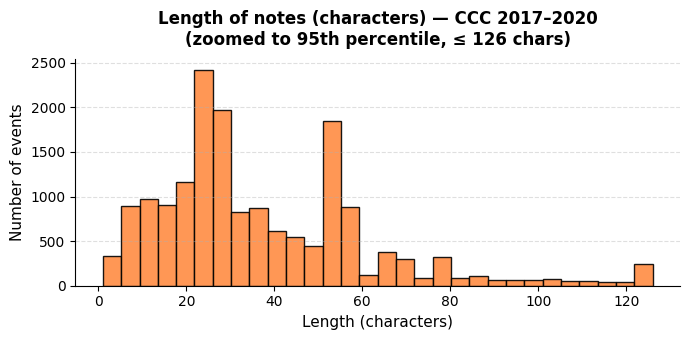


Random sample of 5 notes:


,notes
70933,Rally on Wheels to Cancel Rent Debt & Ban Evic...
67874,gathered across street from protesters; honked...
36578,White House Peace Vigil continuous since June ...
25243,45400 at entire PrideFest weekend
61625,Save the Post Office Saturday


------------------------------------------------------------


### CCC 2021–2024

Rows with notes   : 80,067 (57.26%)
Rows without notes: 59,756


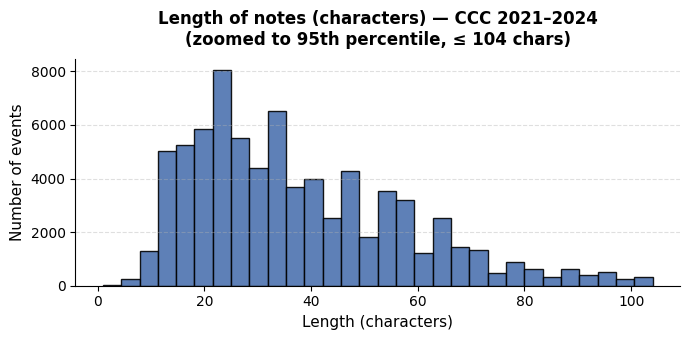


Random sample of 5 notes:


,notes
134750,Protest for Peace in Gaza weekly on Sundays
139094,"Weekly Standout for Palestine every Saturday, ..."
18656,Stop the Mandates Rally
135229,Flashmob Flag Waving USA Trump 2024 Gadsden J6
28698,Bellingham-Whatcom Peace Vigil every Friday si...


------------------------------------------------------------


### CCC 2025+ (Phase 3)

Rows with notes   : 12,500 (42.90%)
Rows without notes: 16,638


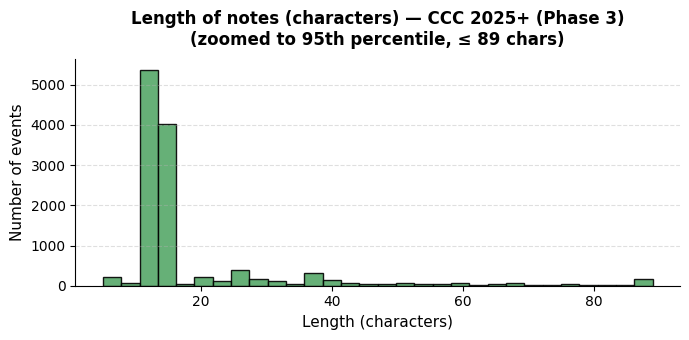


Random sample of 5 notes:


,notes
13275,every Sunday
21644,every Friday
18485,every Friday
1214,daily since 2022
2905,every Sunday


------------------------------------------------------------


In [21]:
datasets = {
    "CCC 2017–2020": (ccc_2017_2020, "#FF8C42"),   # orange
    "CCC 2021–2024": (ccc_2021_2024, "#4C72B0"),   # blue
    "CCC 2025+ (Phase 3)": (ccc_2025_plus, "#55A868"),  # green
}

display(Markdown("## How is the `notes` variable used?"))

def clean_notes_series(s: pd.Series) -> pd.Series:
    return s.astype("string").fillna("").str.strip()

for label, (df, color) in datasets.items():
    display(Markdown(f"### {label}"))

    notes = clean_notes_series(df["notes"])
    has_notes = notes != ""
    n_with = has_notes.sum()
    total = len(notes)

    print(f"Rows with notes   : {n_with:,} ({n_with/total*100:.2f}%)")
    print(f"Rows without notes: {total-n_with:,}")

    # ---------- Length distribution (zoomed) ----------
    lengths = notes[has_notes].str.len()

    if n_with > 0:
        # Zoom to 95th percentile so long outliers don't squash the plot
        max_len_zoom = int(lengths.quantile(0.95))
        lengths_zoom = lengths[lengths <= max_len_zoom]

        plt.figure(figsize=(7, 3.5))
        plt.hist(
            lengths_zoom,
            bins=30,
            edgecolor="black",
            alpha=0.9,
            color=color,
        )
        plt.title(
            f"Length of notes (characters) — {label}\n"
            f"(zoomed to 95th percentile, ≤ {max_len_zoom} chars)",
            fontsize=12,
            fontweight="bold",
            pad=10,
        )
        plt.xlabel("Length (characters)", fontsize=11)
        plt.ylabel("Number of events", fontsize=11)
        plt.grid(axis="y", linestyle="--", alpha=0.4)
        for spine in ["top", "right"]:
            plt.gca().spines[spine].set_visible(False)
        plt.tight_layout()
        plt.show()
    else:
        print("No notes in this phase to plot.")

    # ---------- Random sample to read ----------
    print("\nRandom sample of 5 notes:")
    display(notes[has_notes].sample(min(5, n_with), random_state=0).to_frame("notes"))
    print("-" * 60)

## What are `property_damage` and `property_damage_any`?

### `property_damage`

`property_damage` is a **text field describing any property damage caused by protesters** in an event.

Across phases, coders are instructed to:

- Use **short words or phrases** (e.g., `“graffiti”`, `“broken windows”`, `“toppled statue”`, `“dumpster fire”`).
- Leave the field **blank** if **no property damage is reported**.
- In earlier phases this can sometimes look like a binary code (`0`/`1` or “none”) instead of a descriptive phrase, but conceptually it is meant to describe *what* was damaged.

You should treat `property_damage` as a **qualitative description** of the type of damage, not as a numeric amount.

---

### `property_damage_any`

`property_damage_any` is a **binary indicator derived from `property_damage`**:

- `1` = sources report **some property damage caused by protesters**.  
- `0` = sources indicate **no property damage caused by protesters**.  

In analysis, `property_damage_any` is the clean yes/no variable for **whether any property damage occurred**, while `property_damage` tells you **what kind of damage** it was.


In [22]:
display(Markdown("## Unique values in `property_damage`"))

datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

all_values = []

for name, df in datasets.items():
    s = df["property_damage"].astype("string").str.strip()
    s_nonempty = s[s.notna() & (s != "")]
    
    n_unique = s_nonempty.nunique()
    print(f"{name}: {n_unique:,} unique non-empty values in `property_damage`")
    
    all_values.append(s_nonempty)

# Overall across all phases
all_concat = pd.concat(all_values, ignore_index=True)
overall_unique = all_concat.nunique()
print(f"\nAll phases combined: {overall_unique:,} unique non-empty values in `property_damage`")

## Unique values in `property_damage`

CCC 2017–2020: 11 unique non-empty values in `property_damage`
CCC 2021–2024: 357 unique non-empty values in `property_damage`
CCC 2025+ (Phase 3): 43 unique non-empty values in `property_damage`

All phases combined: 405 unique non-empty values in `property_damage`


## Property damage indicators by phase

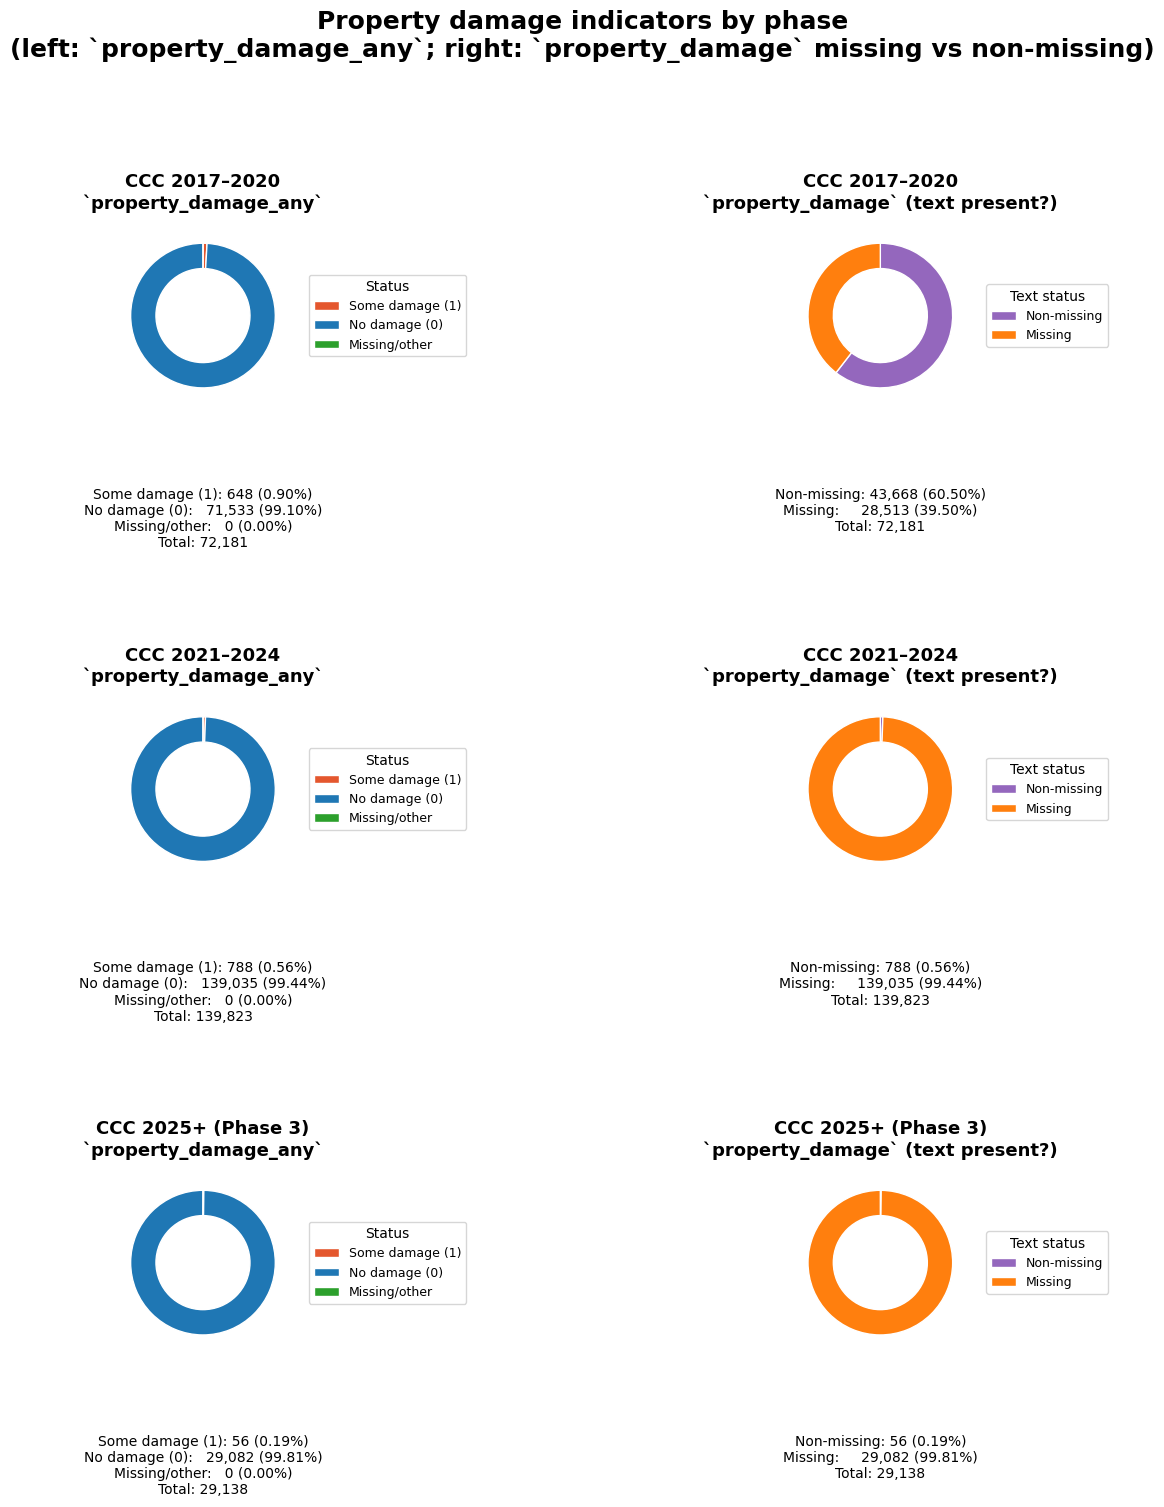

In [23]:
display(Markdown("## Property damage indicators by phase"))

datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

# --- helpers -------------------------------------------------
def prop_damage_any_counts(series: pd.Series):
    """Counts for property_damage_any: some / none / missing."""
    s = pd.to_numeric(series, errors="coerce")
    total = len(s)
    n_some = (s == 1).sum()
    n_none = (s == 0).sum()
    n_missing = total - n_some - n_none
    return n_some, n_none, n_missing, total

def prop_damage_missing_counts(series: pd.Series):
    """Counts for property_damage: non-missing / missing."""
    s = series.astype("string").fillna("").str.strip()
    n_non_missing = (s != "").sum()
    n_missing = (s == "").sum()
    total = len(s)
    return n_non_missing, n_missing, total

# --- figure: 3 rows (phases) x 2 columns (any vs detail) -----
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# Vibrant colors
pd_any_colors = {
    "Some damage (1)": "#E4572E",   # red-orange
    "No damage (0)":   "#1F77B4",   # strong blue
    "Missing/other":   "#2CA02C",   # green
}

pd_missing_colors = {
    "Non-missing": "#9467BD",      # purple
    "Missing":     "#FF7F0E",      # orange
}

for row_idx, (label, df) in enumerate(datasets.items()):
    # ---------- LEFT: property_damage_any ----------
    ax_left = axes[row_idx, 0]
    n_some, n_none, n_missing_any, total_any = prop_damage_any_counts(df["property_damage_any"])

    sizes_any = [n_some, n_none, n_missing_any]
    labels_any = ["Some damage (1)", "No damage (0)", "Missing/other"]
    colors_any = [pd_any_colors[c] for c in labels_any]

    wedges_any, _ = ax_left.pie(
        sizes_any,
        labels=None,
        colors=colors_any,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.35, edgecolor="white"),
    )

    ax_left.set_title(f"{label}\n`property_damage_any`",
                      fontsize=13, fontweight="bold", pad=12)
    ax_left.set_aspect("equal")

    ax_left.legend(
        wedges_any,
        labels_any,
        title="Status",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        fontsize=9,
        title_fontsize=10,
    )

    pct_some = (n_some / total_any * 100) if total_any > 0 else 0.0
    pct_none = (n_none / total_any * 100) if total_any > 0 else 0.0
    pct_missing_any = (n_missing_any / total_any * 100) if total_any > 0 else 0.0

    summary_any = (
        f"Some damage (1): {n_some:,} ({pct_some:.2f}%)\n"
        f"No damage (0):   {n_none:,} ({pct_none:.2f}%)\n"
        f"Missing/other:   {n_missing_any:,} ({pct_missing_any:.2f}%)\n"
        f"Total: {total_any:,}"
    )
    ax_left.text(
        0.5, -0.45, summary_any,
        transform=ax_left.transAxes,
        ha="center",
        va="top",
        fontsize=10,
    )

    # ---------- RIGHT: property_damage (missing vs non) ----------
    ax_right = axes[row_idx, 1]
    n_non_missing, n_missing, total_pd = prop_damage_missing_counts(df["property_damage"])

    sizes_pd = [n_non_missing, n_missing]
    labels_pd = ["Non-missing", "Missing"]
    colors_pd = [pd_missing_colors[c] for c in labels_pd]

    wedges_pd, _ = ax_right.pie(
        sizes_pd,
        labels=None,
        colors=colors_pd,
        startangle=90,
        counterclock=False,
        wedgeprops=dict(width=0.35, edgecolor="white"),
    )

    ax_right.set_title(f"{label}\n`property_damage` (text present?)",
                       fontsize=13, fontweight="bold", pad=12)
    ax_right.set_aspect("equal")

    ax_right.legend(
        wedges_pd,
        labels_pd,
        title="Text status",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        fontsize=9,
        title_fontsize=10,
    )

    pct_non_missing = (n_non_missing / total_pd * 100) if total_pd > 0 else 0.0
    pct_missing = (n_missing / total_pd * 100) if total_pd > 0 else 0.0

    summary_pd = (
        f"Non-missing: {n_non_missing:,} ({pct_non_missing:.2f}%)\n"
        f"Missing:     {n_missing:,} ({pct_missing:.2f}%)\n"
        f"Total: {total_pd:,}"
    )
    ax_right.text(
        0.5, -0.45, summary_pd,
        transform=ax_right.transAxes,
        ha="center",
        va="top",
        fontsize=10,
    )

plt.suptitle(
    "Property damage indicators by phase\n(left: `property_damage_any`; right: `property_damage` missing vs non-missing)",
    fontsize=18,
    fontweight="bold",
    y=0.99,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## `property_damage` descriptions by phase

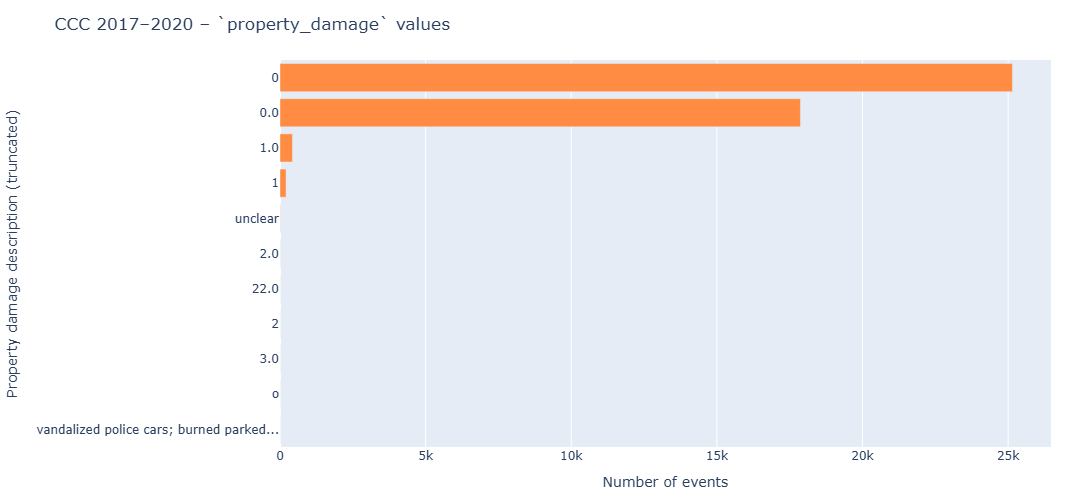

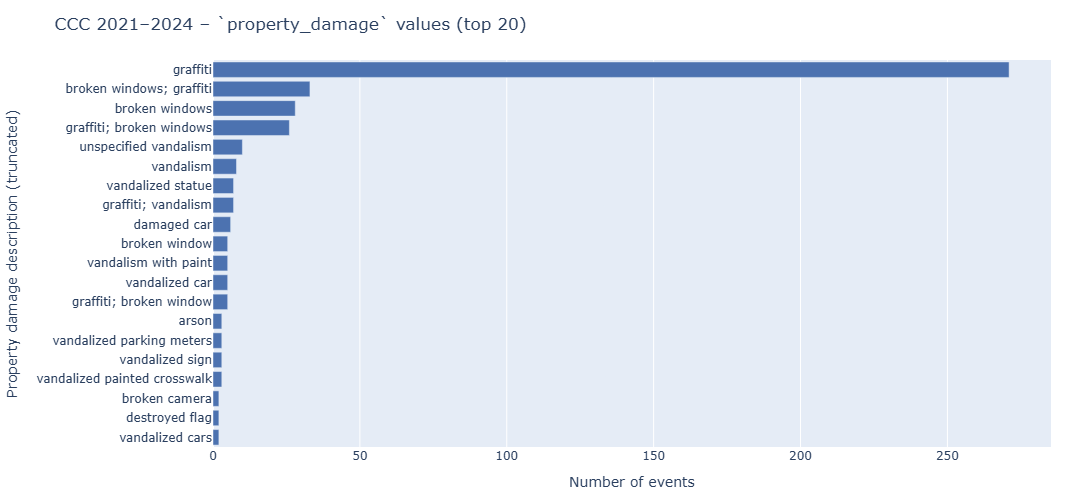

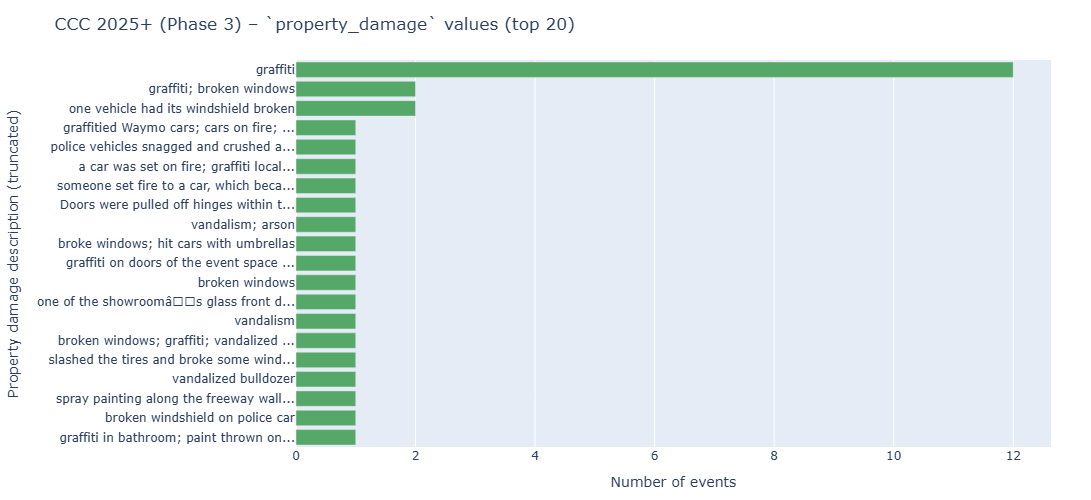

In [24]:
display(Markdown("## `property_damage` descriptions by phase"))

def clean_prop_damage(series: pd.Series) -> pd.Series:
    s = series.astype("string").fillna("").str.strip()
    return s[s != ""]   # drop empty

def prep_phase_df(df, phase_label, top_n=None, max_len=40):
    s = clean_prop_damage(df["property_damage"])
    counts = s.value_counts()
    if top_n is not None:
        counts = counts.head(top_n)

    counts = counts.sort_values(ascending=True)

    out = counts.reset_index()
    out.columns = ["full_label", "count"]

    out["short_label"] = out["full_label"].apply(
        lambda txt: txt if len(txt) <= max_len else txt[: max_len - 3] + "..."
    )
    out["phase"] = phase_label
    return out

# (phase label, df, color, top_n)
phases = [
    ("CCC 2017–2020", ccc_2017_2020, "#FF8C42", None),   # all values (11)
    ("CCC 2021–2024", ccc_2021_2024, "#4C72B0", 20),     # top 20
    ("CCC 2025+ (Phase 3)", ccc_2025_plus, "#55A868", 20),
]

for phase_label, df, color, top_n in phases:
    phase_df = prep_phase_df(df, phase_label, top_n=top_n)

    subtitle = "" if top_n is None else f" (top {top_n})"
    title = f"{phase_label} – `property_damage` values{subtitle}"

    fig = px.bar(
        phase_df,
        x="count",
        y="short_label",
        orientation="h",
        title=title,
    )

    fig.update_traces(
        marker_color=color,
        customdata=phase_df[["full_label"]].to_numpy(),
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"  # full property_damage text
            "Count: %{x}<extra></extra>"
        ),
    )

    fig.update_layout(
        xaxis_title="Number of events",
        yaxis_title="Property damage description (truncated)",
        margin=dict(l=140, r=40, t=60, b=40),
        height=500,
    )

    fig.show()

## What about the size variables?

### `size_text`
- **Type:** free text
- **What it is:** The *exact words/phrases* that sources use to describe crowd size.  
  - Examples: `"about 200"`, `"hundreds"`, `"a few dozen"`, `"30–40"`, `"more than 1,000"`.
- Used as the **raw input** from which numeric estimates are derived.

---

### `size_low`
- **Type:** integer
- **What it is:** The **lowest** reported/estimated crowd size for the event, derived from `size_text`.  
- Rules (applied consistently in all phases):
  - Convert vague phrases to numbers using fixed rules (e.g., “hundreds” → 200, “thousands” → 2,000).  
  - For ranges (e.g., “30–40”), record the **low end** here (30).  
  - If coders estimate from photos/video, they record their **low estimate** here.

---

### `size_high`
- **Type:** integer
- **What it is:** The **highest** reported/estimated crowd size, derived from `size_text`.
- Rules parallel to `size_low`:
  - Same conversion rules for vague phrases.
  - For ranges, record the **high end** here (e.g., 40 for “30–40”).  
  - If estimated from photos/video, this is the **high estimate**.

---

### `size_mean`
- **Type:** integer
- **What it is:** The **average** of `size_low` and `size_high`, **rounded up** to the nearest integer.
- This is the main numeric size you’ll usually use for analysis:
  
  \[
  \text{size\_mean} = \lceil (\text{size\_low} + \text{size\_high}) / 2 \rceil
  \]

---

### `size_cat`
- **Type:** **ordered categorical** variable (ordinal), derived from `size_mean`.
- **What it is:** A *binned* version of crowd size, in orders of magnitude.  
- **Categories (same in Phase 1 & Phase 2; Phase 3 uses the same idea):**

  - `0` = **Unknown**  
  - `1` = **1–99** (tens)  
  - `2` = **100–999** (hundreds)  
  - `3` = **1,000–9,999** (thousands)  
  - `4` = **10,000+** (tens of thousands and above)

So, in short:

- `size_text` = words
- `size_low` / `size_high` = numeric interval
- `size_mean` = single numeric estimate  
- `size_cat` = **category/band** of crowd size based on that estimate.


## Distributions of `size_low`, `size_mean`, and `size_high` by phase

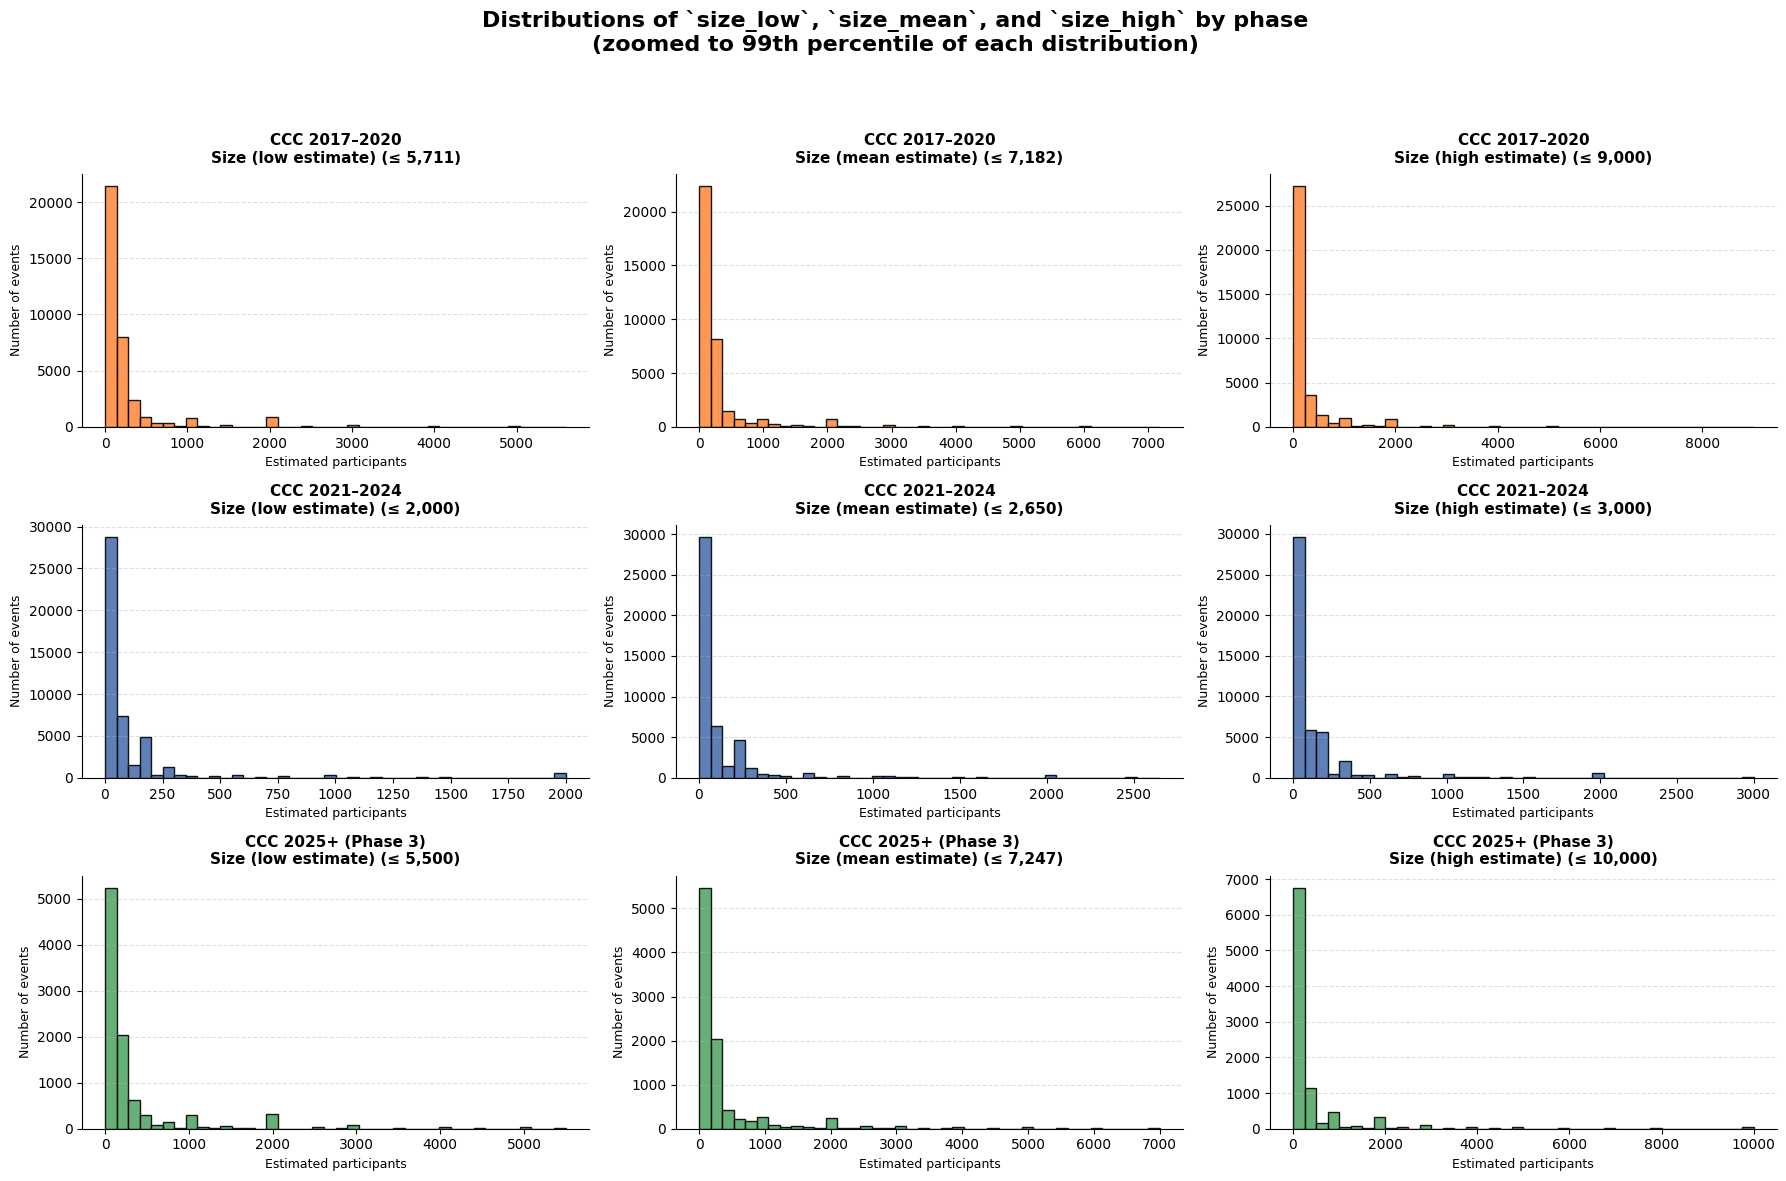

In [25]:
display(Markdown("## Distributions of `size_low`, `size_mean`, and `size_high` by phase"))

# Phase dictionary: name, df, color (per phase)
datasets = {
    "CCC 2017–2020": (ccc_2017_2020, "#FF8C42"),   # orange
    "CCC 2021–2024": (ccc_2021_2024, "#4C72B0"),   # blue
    "CCC 2025+ (Phase 3)": (ccc_2025_plus, "#55A868"),  # green
}

size_vars = [
    ("size_low", "Size (low estimate)"),
    ("size_mean", "Size (mean estimate)"),
    ("size_high", "Size (high estimate)"),
]

fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(18, 12),
    sharex=False, sharey=False
)

for row_idx, (phase_name, (df, color)) in enumerate(datasets.items()):
    for col_idx, (col_name, col_label) in enumerate(size_vars):
        ax = axes[row_idx, col_idx]

        # Convert to numeric and drop missing
        s = pd.to_numeric(df[col_name], errors="coerce").dropna()

        if len(s) == 0:
            ax.text(0.5, 0.5, "No data",
                    ha="center", va="center", fontsize=10)
            ax.set_title(f"{phase_name}\n{col_label}", fontsize=11, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.set_xticks([])
            ax.set_yticks([])
            continue

        # Zoom to 99th percentile so huge outliers don't squash the plot
        p99 = s.quantile(0.99)
        s_plot = s[s <= p99]

        ax.hist(
            s_plot,
            bins=40,
            edgecolor="black",
            alpha=0.9,
            color=color,
        )

        ax.set_title(
            f"{phase_name}\n{col_label} (≤ {int(p99):,})",
            fontsize=11,
            fontweight="bold",
            pad=8,
        )
        ax.set_xlabel("Estimated participants", fontsize=9)
        ax.set_ylabel("Number of events", fontsize=9)

        ax.grid(axis="y", linestyle="--", alpha=0.4)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

plt.suptitle(
    "Distributions of `size_low`, `size_mean`, and `size_high` by phase\n(zoomed to 99th percentile of each distribution)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## Distribution of `size_cat` by phase (including missing)

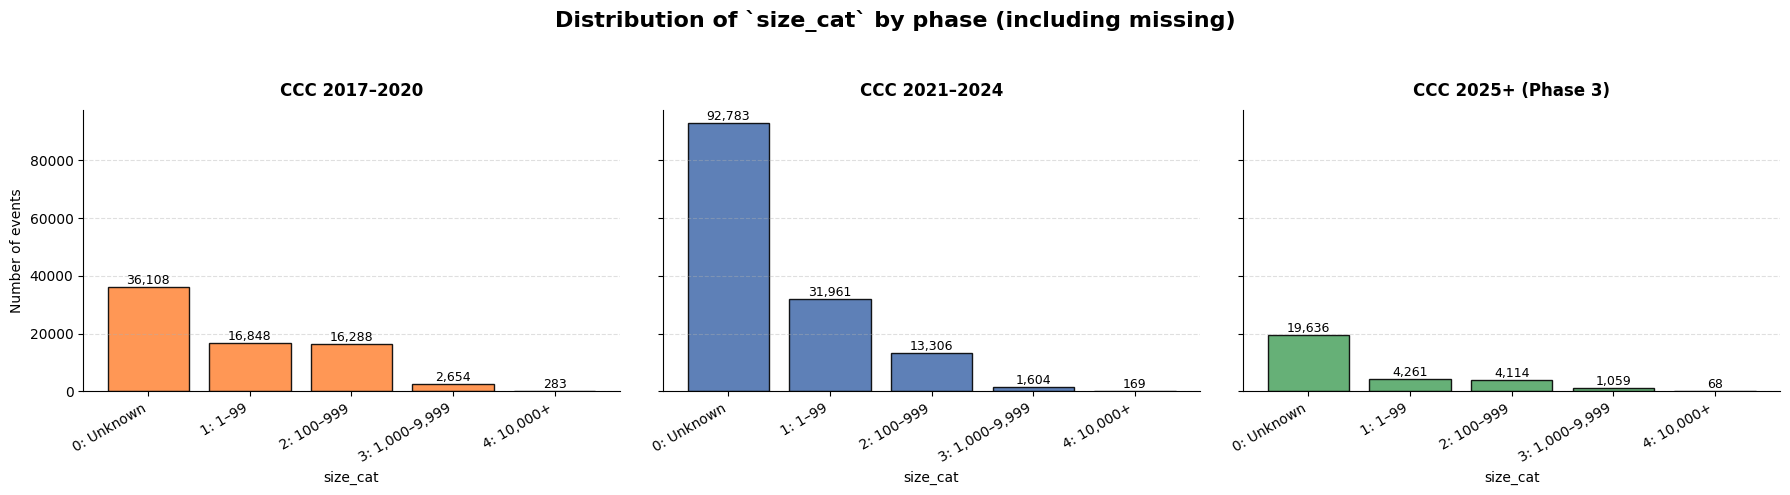

In [26]:
display(Markdown("## Distribution of `size_cat` by phase (including missing)"))

# Phase dictionary: name, df, color
datasets = {
    "CCC 2017–2020": (ccc_2017_2020, "#FF8C42"),   # orange
    "CCC 2021–2024": (ccc_2021_2024, "#4C72B0"),   # blue
    "CCC 2025+ (Phase 3)": (ccc_2025_plus, "#55A868"),  # green
}

# Optional: labels for known numeric categories
size_cat_labels = {
    0: "0: Unknown",
    1: "1: 1–99",
    2: "2: 100–999",
    3: "3: 1,000–9,999",
    4: "4: 10,000+",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (phase_name, (df, color)) in zip(axes, datasets.items()):
    s_raw = df["size_cat"]

    # numeric parse
    s_num = pd.to_numeric(s_raw, errors="coerce")
    valid_mask = s_num.notna()
    numeric_counts = s_num[valid_mask].value_counts().sort_index()

    # missing = anything that didn't parse to numeric
    missing_count = (~valid_mask).sum()

    # Build combined index: numeric codes + "Missing" (if any)
    counts_dict = {int(k): v for k, v in numeric_counts.items()}
    if missing_count > 0:
        counts_dict["Missing"] = missing_count

    # Ensure deterministic order: numeric codes ascending, then "Missing"
    numeric_keys = sorted(k for k in counts_dict.keys() if isinstance(k, int))
    if "Missing" in counts_dict:
        x_codes = numeric_keys + ["Missing"]
    else:
        x_codes = numeric_keys

    counts_vals = [counts_dict[k] for k in x_codes]

    # Build x-axis labels
    x_labels = []
    for code in x_codes:
        if code == "Missing":
            x_labels.append("Missing")
        else:
            x_labels.append(size_cat_labels.get(code, str(code)))

    bars = ax.bar(
        range(len(x_codes)),
        counts_vals,
        color=color,
        edgecolor="black",
        alpha=0.9,
    )

    ax.set_title(phase_name, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("size_cat", fontsize=10)
    ax.set_xticks(range(len(x_codes)))
    ax.set_xticklabels(x_labels, rotation=30, ha="right")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    if ax is axes[0]:
        ax.set_ylabel("Number of events", fontsize=10)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Add counts above bars
    for bar, val in zip(bars, counts_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(val):,}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

plt.suptitle(
    "Distribution of `size_cat` by phase (including missing)",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## What is the `valence` variable?

`valence` captures the **political orientation of the event’s claims on a left–right spectrum**.

Across phases, it is coded as:

- **2** – right-wing  
- **1** – left-wing  
- **0** – other / neither  

In **Phase 1 (2017–2020)**, this was originally defined relative to Trump:

- 2 = *pro-Trump*  
- 1 = *anti-Trump*  
- 0 = other / neither :contentReference[oaicite:0]{index=0}  

In **Phase 2 (2021–2024)** and **Phase 3 (2025+)**, the same numeric codes are used in a more general way:

- 2 = right-wing  
- 1 = left-wing  
- 0 = other or neither   

Coders judge `valence` based on:

- The groups involved (e.g., Democratic vs. Republican organizations), and  
- The **substance of claims**, using the coding guidelines for consistency across similar issues.
::contentReference[oaicite:2]{index=2}


## Horizontal bubble chart of `valence` by phase

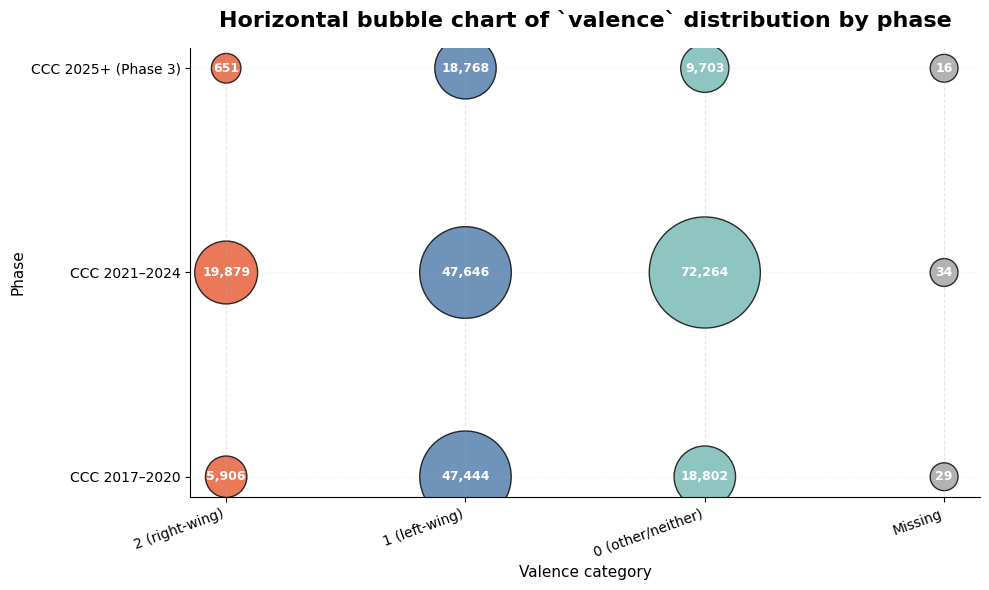

In [27]:
display(Markdown("## Horizontal bubble chart of `valence` by phase"))

datasets = {
    "CCC 2017–2020": ccc_2017_2020,
    "CCC 2021–2024": ccc_2021_2024,
    "CCC 2025+ (Phase 3)": ccc_2025_plus,
}

def valence_counts(series: pd.Series):
    s = pd.to_numeric(series, errors="coerce")
    total = len(s)

    n2 = (s == 2).sum()
    n1 = (s == 1).sum()
    n0 = (s == 0).sum()
    n_missing = total - (n2 + n1 + n0)

    return n2, n1, n0, n_missing, total

phase_names = list(datasets.keys())
categories = ["2", "1", "0", "Missing"]
cat_labels = {
    "2": "2 (right-wing)",
    "1": "1 (left-wing)",
    "0": "0 (other/neither)",
    "Missing": "Missing",
}
colors = {
    "2": "#E4572E",      # red-orange
    "1": "#4C78A8",      # blue
    "0": "#72B7B2",      # teal
    "Missing": "#A0A0A0" # gray
}

# Build bubble dataframe
bubble_data = []
for phase in phase_names:
    df = datasets[phase]
    n2, n1, n0, n_missing, total = valence_counts(df["valence"])
    bubble_data.append({"phase": phase, "cat": "2", "count": n2})
    bubble_data.append({"phase": phase, "cat": "1", "count": n1})
    bubble_data.append({"phase": phase, "cat": "0", "count": n0})
    bubble_data.append({"phase": phase, "cat": "Missing", "count": n_missing})

bubble_df = pd.DataFrame(bubble_data)

# Map categories and phases to positions
x_positions = {cat: i for i, cat in enumerate(categories)}
y_positions = {phase: i for i, phase in enumerate(phase_names)}

bubble_df["x"] = bubble_df["cat"].map(x_positions)
bubble_df["y"] = bubble_df["phase"].map(y_positions)

# Bubble sizes: bigger overall
max_count = bubble_df["count"].max() if bubble_df["count"].max() > 0 else 1
bubble_df["size"] = (bubble_df["count"] / max_count) * 6000 + 400

fig, ax = plt.subplots(figsize=(10, 6))

for cat in categories:
    subset = bubble_df[bubble_df["cat"] == cat]
    ax.scatter(
        subset["x"],
        subset["y"],
        s=subset["size"],
        color=colors[cat],
        alpha=0.8,
        edgecolor="black",
    )

    # Count labels on bubbles
    for _, row in subset.iterrows():
        if row["count"] > 0:
            ax.text(
                row["x"],
                row["y"],
                f"{int(row['count']):,}",
                ha="center",
                va="center",
                fontsize=9,
                color="white",
                weight="bold",
            )

# Axis formatting
ax.set_xticks(range(len(categories)))
ax.set_xticklabels([cat_labels[c] for c in categories], rotation=20, ha="right")
ax.set_yticks(range(len(phase_names)))
ax.set_yticklabels(phase_names)

ax.set_xlabel("Valence category", fontsize=11)
ax.set_ylabel("Phase", fontsize=11)
ax.set_title("Horizontal bubble chart of `valence` distribution by phase",
             fontsize=16, fontweight="bold", pad=15)

ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.grid(axis="y", linestyle="--", alpha=0.1)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# This concludes all the variables that are common among the 3 phases

# Now we look at variables that have the same concept but have different names

## Location within locality

Across all three phases, the CCC uses a free-text field to describe **where within the locality the event took place**.  

- In Phases 1–2 this column is named **`location_detail`**.  
- In Phase 3 this column is named **`location`**.  

Conceptually, they are the *same variable*:

> A short description of the specific site inside the town/city where the event occurred.

Examples of entries:

- “city hall steps”  
- “county courthouse”  
- “intersection of 5th & Main”  
- “state capitol lawn”  
- “police headquarters”  
- “university quad”  

In analysis, you can safely combine them into a single conceptual field like **“location within locality”**, using `location_detail` for Phases 1–2 and `location` for Phase 3.


## How many null "location within locality" values does each phase have?

CCC 2017–2020: 8,768 null/empty spots
CCC 2021–2024: 9,804 null/empty spots
CCC 2025+ (Phase 3): 1,602 null/empty spots


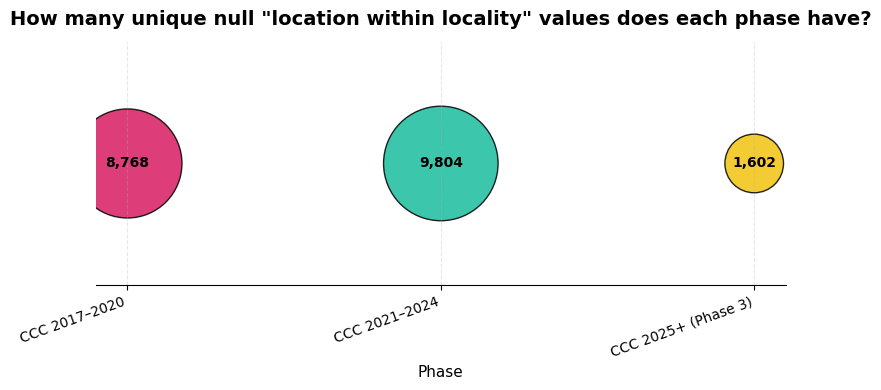

In [28]:
display(Markdown("## How many null \"location within locality\" values does each phase have?"))

def count_null_spots(series: pd.Series) -> int:
    s = series.astype("string").fillna("").str.strip()
    return (s == "").sum()

# Phase → (df, column name)
phases = {
    "CCC 2017–2020": (ccc_2017_2020, "location_detail"),
    "CCC 2021–2024": (ccc_2021_2024, "location_detail"),
    "CCC 2025+ (Phase 3)": (ccc_2025_plus, "location"),
}

# New color palette (magenta, teal, gold)
phase_colors = {
    "CCC 2017–2020": "#D81B60",   # magenta
    "CCC 2021–2024": "#1ABC9C",   # teal
    "CCC 2025+ (Phase 3)": "#F1C40F",  # gold
}

phase_names = []
null_counts = []
colors = []

for phase_label, (df, col) in phases.items():
    n_null = count_null_spots(df[col])
    phase_names.append(phase_label)
    null_counts.append(n_null)
    colors.append(phase_colors[phase_label])
    print(f"{phase_label}: {n_null:,} null/empty spots")

# --- Bubble chart ---
fig, ax = plt.subplots(figsize=(8, 4))

x = range(len(phase_names))
y = [0] * len(phase_names)  # single row

max_count = max(null_counts) if max(null_counts) > 0 else 1
sizes = [(c / max_count) * 6000 + 800 for c in null_counts]  # bigger base size

ax.scatter(
    x,
    y,
    s=sizes,
    c=colors,
    alpha=0.85,
    edgecolor="black",
)

# Add count labels on bubbles
for xi, yi, c in zip(x, y, null_counts):
    ax.text(
        xi,
        yi,
        f"{int(c):,}",
        ha="center",
        va="center",
        fontsize=10,
        color="black",   # better contrast with bright fills
        weight="bold",
    )

ax.set_xticks(x)
ax.set_xticklabels(phase_names, rotation=20, ha="right")
ax.set_yticks([])

ax.set_title("How many unique null \"location within locality\" values does each phase have?",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Phase", fontsize=11)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## How many unique spots does each phase have?

CCC 2017–2020: 37,331 unique non-empty spots
CCC 2021–2024: 41,190 unique non-empty spots
CCC 2025+ (Phase 3): 12,171 unique non-empty spots


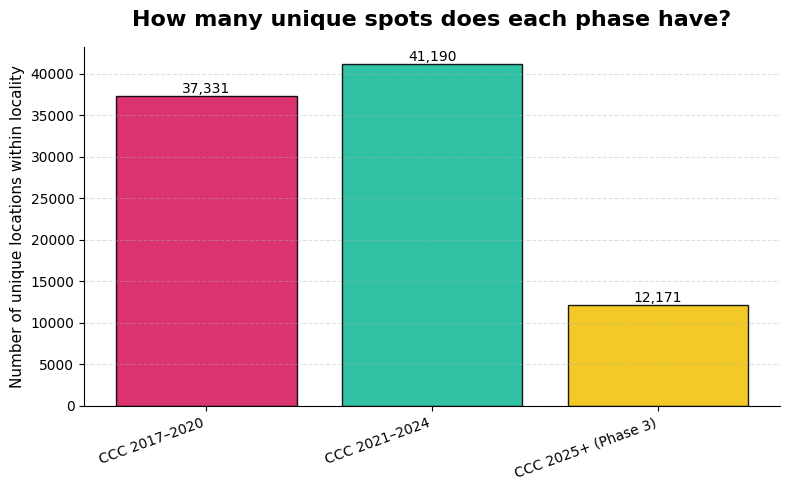

In [29]:
display(Markdown("## How many unique spots does each phase have?"))

def count_unique_spots(series: pd.Series) -> int:
    s = series.astype("string").fillna("").str.strip()
    s_nonempty = s[s != ""]
    return s_nonempty.nunique()

# Map phase name -> (DataFrame, column name)
phases = {
    "CCC 2017–2020": (ccc_2017_2020, "location_detail"),
    "CCC 2021–2024": (ccc_2021_2024, "location_detail"),
    "CCC 2025+ (Phase 3)": (ccc_2025_plus, "location"),
}

# New colors per phase
phase_colors = {
    "CCC 2017–2020": "#D81B60",   # magenta
    "CCC 2021–2024": "#1ABC9C",   # teal
    "CCC 2025+ (Phase 3)": "#F1C40F",  # gold
}

phase_names = []
unique_counts = []
colors = []

for phase_label, (df, col) in phases.items():
    n_unique = count_unique_spots(df[col])
    phase_names.append(phase_label)
    unique_counts.append(n_unique)
    colors.append(phase_colors[phase_label])
    print(f"{phase_label}: {n_unique:,} unique non-empty spots")

# --- Bar chart ---
plt.figure(figsize=(8, 5))

bars = plt.bar(phase_names, unique_counts, color=colors, edgecolor="black", alpha=0.9)

plt.title("How many unique spots does each phase have?", fontsize=16, fontweight="bold", pad=15)
plt.ylabel("Number of unique locations within locality", fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)

for spine in ["top", "right"]:
    plt.gca().spines[spine].set_visible(False)

# Add counts above bars
for bar, val in zip(bars, unique_counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(val):,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

## Unique locations within locality by resolved county

,phase,resolved_county,n_unique_locations
0,CCC 2017–2020,Acadia Parish,3
1,CCC 2017–2020,Accomack County,6
2,CCC 2017–2020,Ada County,87
3,CCC 2017–2020,Adair County,6
4,CCC 2017–2020,Adams County,40


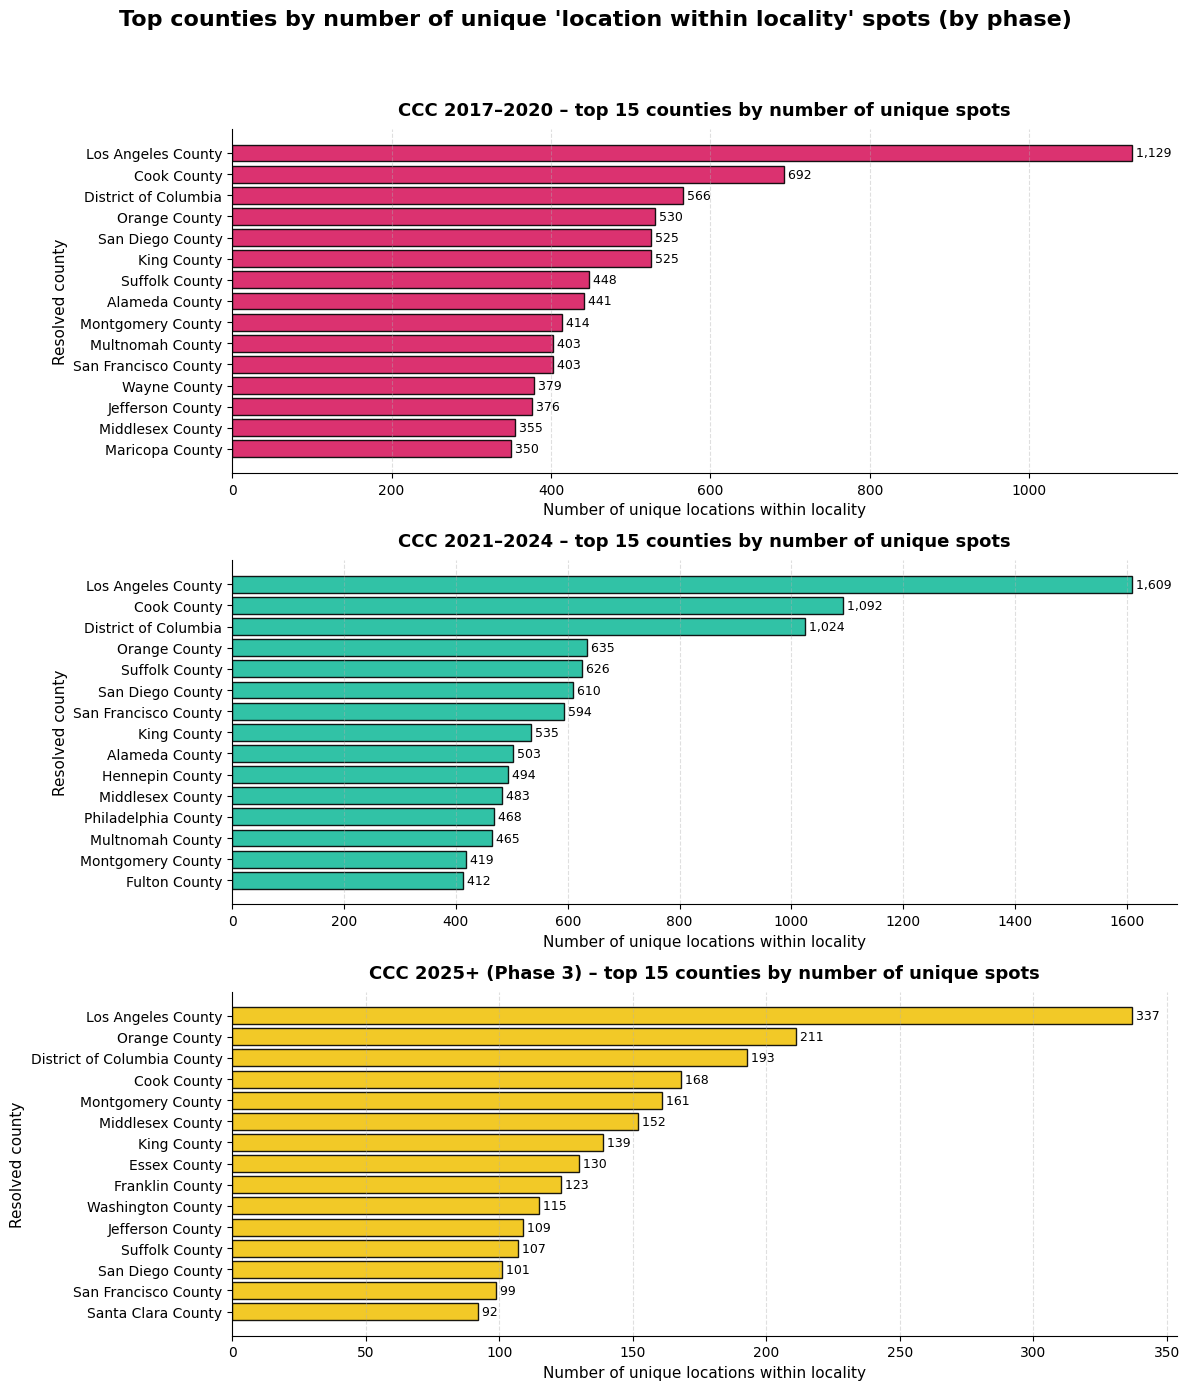

In [30]:
display(Markdown("## Unique locations within locality by resolved county"))

# ---------- Build unified location_within_locality ----------
p1 = ccc_2017_2020.copy()
p2 = ccc_2021_2024.copy()
p3 = ccc_2025_plus.copy()

p1["phase"] = "CCC 2017–2020"
p2["phase"] = "CCC 2021–2024"
p3["phase"] = "CCC 2025+ (Phase 3)"

p1["location_within_locality"] = (
    p1["location_detail"].astype("string").fillna("").str.strip()
)
p2["location_within_locality"] = (
    p2["location_detail"].astype("string").fillna("").str.strip()
)
p3["location_within_locality"] = (
    p3["location"].astype("string").fillna("").str.strip()
)

# Treat empty strings as missing
for df in (p1, p2, p3):
    df["location_within_locality"] = df["location_within_locality"].replace("", pd.NA)

# Combine all phases
all_loc = pd.concat([p1, p2, p3], ignore_index=True)

# ---------- Group by phase & resolved_county ----------
grouped_locations = (
    all_loc
    .dropna(subset=["resolved_county", "location_within_locality"])
    .groupby(["phase", "resolved_county"])["location_within_locality"]
    .nunique()
    .reset_index(name="n_unique_locations")
)

display(grouped_locations.head())

# ---------- Plot: top N counties per phase ----------
TOP_N = 15

phases = [
    "CCC 2017–2020",
    "CCC 2021–2024",
    "CCC 2025+ (Phase 3)",
]

phase_colors = {
    "CCC 2017–2020": "#D81B60",   # magenta
    "CCC 2021–2024": "#1ABC9C",   # teal
    "CCC 2025+ (Phase 3)": "#F1C40F",  # gold
}

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

for ax, phase in zip(axes, phases):
    df_phase = grouped_locations[grouped_locations["phase"] == phase]

    if df_phase.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=11)
        ax.set_title(phase, fontsize=13, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    top_counties = (
        df_phase.sort_values("n_unique_locations", ascending=False)
        .head(TOP_N)
        .sort_values("n_unique_locations", ascending=True)  # for nicer bar order
    )

    bars = ax.barh(
        top_counties["resolved_county"],
        top_counties["n_unique_locations"],
        color=phase_colors[phase],
        edgecolor="black",
        alpha=0.9,
    )

    ax.set_title(
        f"{phase} – top {TOP_N} counties by number of unique spots",
        fontsize=13,
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("Number of unique locations within locality", fontsize=11)
    ax.set_ylabel("Resolved county", fontsize=11)

    ax.grid(axis="x", linestyle="--", alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Add labels at end of bars
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f" {int(width):,}",
            va="center",
            ha="left",
            fontsize=9,
        )

plt.suptitle(
    "Top counties by number of unique 'location within locality' spots (by phase)",
    fontsize=16,
    fontweight="bold",
    y=0.99,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## I think this plot tells us that since there are so many unique locations where people have gathered to protest within a county, it is safe to assume a location level analysis is not significant.

## Event type

Across all three phases, the CCC has a variable that describes **what kind of event it was**, i.e. the *form* of collective action, not its issue or ideology.

- In **Phases 1–2**, this variable is named **`type`**.  
- In **Phase 3**, it is renamed **`event_type`**.  

Conceptually, they are the same thing:

> A categorical code indicating the **type of event**, such as whether it is a march, rally, vigil, counter-protest, strike, blockade, occupation, etc.

Key points:

- One code per row, summarizing the **main form of the action**.
- Distinct from:
  - `valence` (political orientation)
  - `issues` / `issue_tags` (what the protest is about)
  - `size_*` (how many people participated)
- In analysis, you can treat `type` (Phases 1–2) and `event_type` (Phase 3) as a single conceptual variable, e.g. **“event_type”**, after harmonizing the category labels if needed.


## Event type (`type` / `event_type`): nulls and top 10 types

CCC 2017–2020: total=72,181, non-null=71,754, null=427, unique non-null=744
CCC 2021–2024: total=139,823, non-null=139,774, null=49, unique non-null=531
CCC 2025+ (Phase 3): total=29,138, non-null=29,041, null=97, unique non-null=104


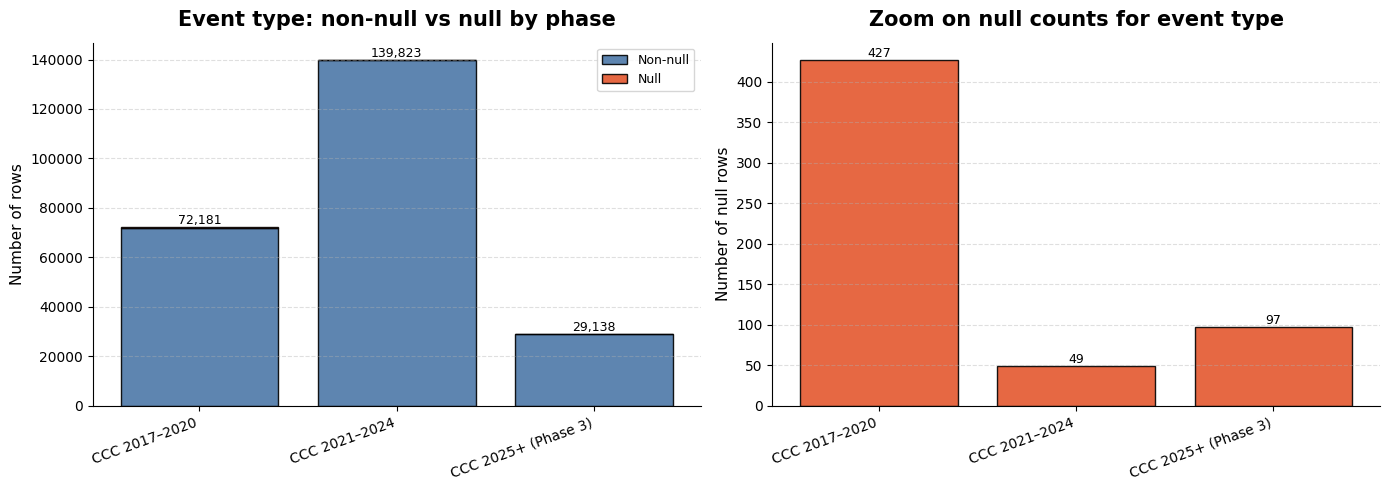

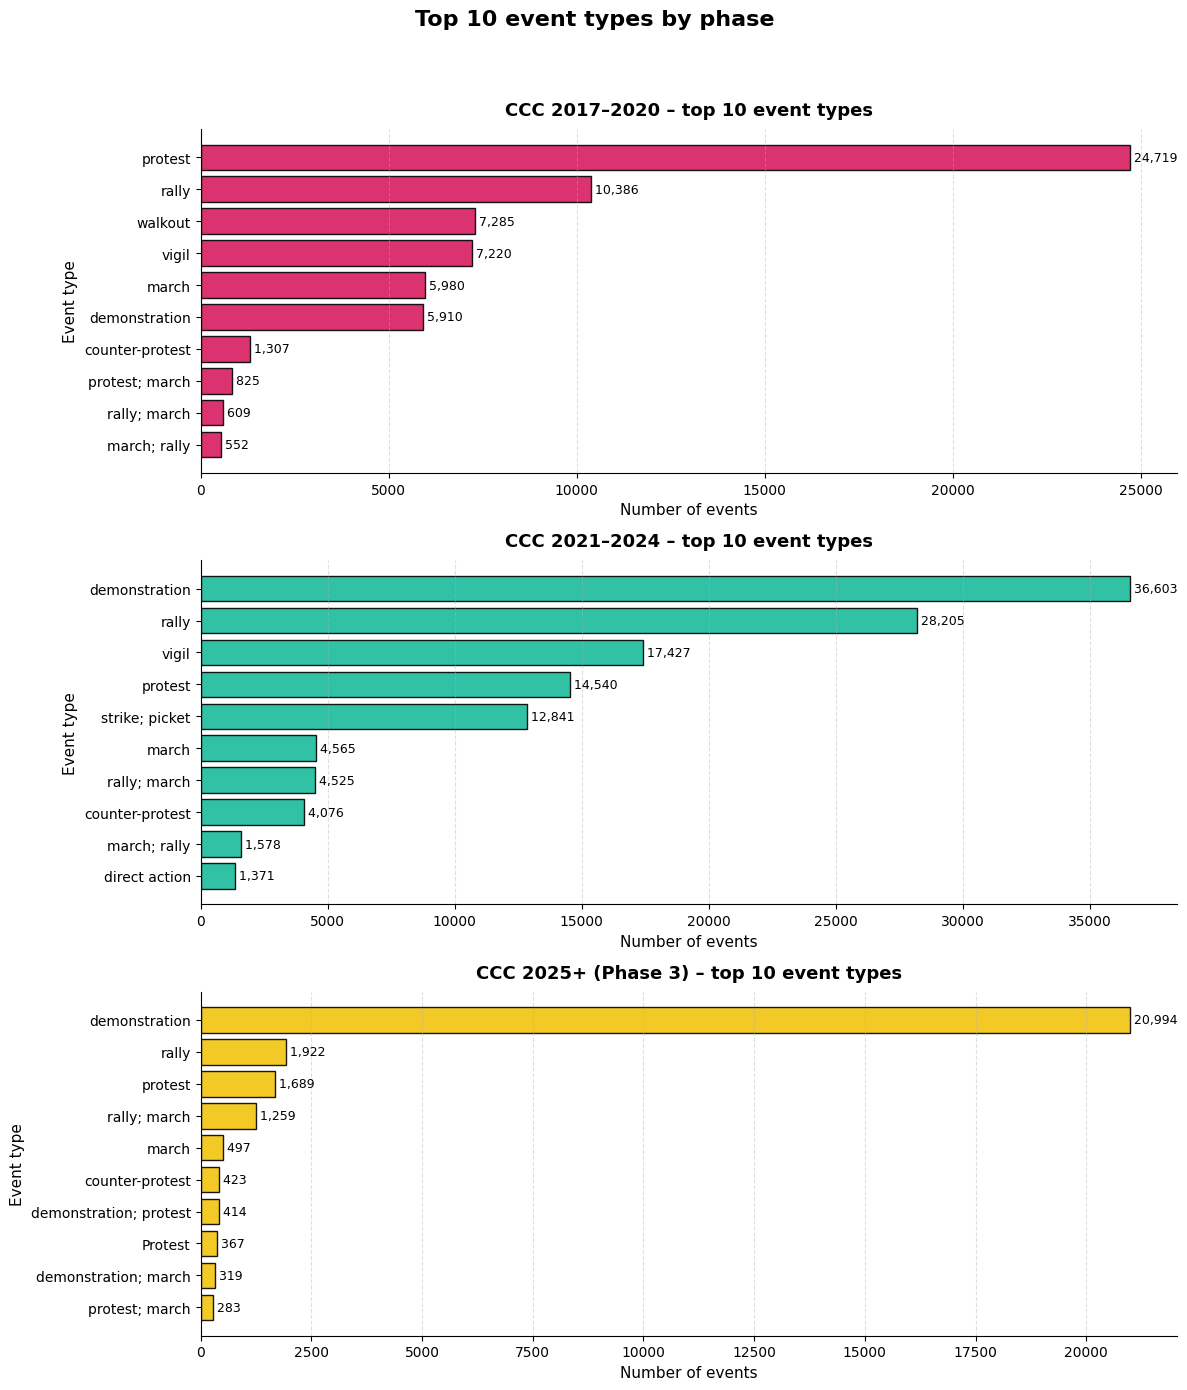

In [31]:
display(Markdown("## Event type (`type` / `event_type`): nulls and top 10 types"))

# ---------- Helper ----------

def clean_event_type(series: pd.Series) -> pd.Series:
    s = series.astype("string").fillna("").str.strip()
    s = s.replace("", pd.NA)  # treat empty as missing
    return s

# phase label -> (df, column name)
phase_info = {
    "CCC 2017–2020": (ccc_2017_2020, "type"),
    "CCC 2021–2024": (ccc_2021_2024, "type"),
    "CCC 2025+ (Phase 3)": (ccc_2025_plus, "event_type"),
}

phase_names = list(phase_info.keys())

# Colors per phase for the type distributions
phase_colors = {
    "CCC 2017–2020": "#D81B60",   # magenta
    "CCC 2021–2024": "#1ABC9C",   # teal
    "CCC 2025+ (Phase 3)": "#F1C40F",  # gold
}

# ---------- Compute stats ----------

non_null_counts = []
null_counts = []
totals = []
value_counts_by_phase = {}

for phase_label, (df, col) in phase_info.items():
    s = clean_event_type(df[col])
    total = len(s)
    n_null = s.isna().sum()
    n_non_null = total - n_null

    totals.append(total)
    null_counts.append(n_null)
    non_null_counts.append(n_non_null)

    vc = s.value_counts().sort_values(ascending=False)
    value_counts_by_phase[phase_label] = vc

    print(
        f"{phase_label}: total={total:,}, "
        f"non-null={n_non_null:,}, null={n_null:,}, "
        f"unique non-null={vc.index.nunique():,}"
    )

# =========================================================
# Figure 1: stacked bars + "zoom" on null counts
# =========================================================

fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(phase_names))

# --- Left: stacked bars (non-null vs null) ---

bars_non_null = ax_main.bar(
    x,
    non_null_counts,
    color="#4C78A8",
    edgecolor="black",
    alpha=0.9,
    label="Non-null",
)

bars_null = ax_main.bar(
    x,
    null_counts,
    bottom=non_null_counts,
    color="#E4572E",
    edgecolor="black",
    alpha=0.9,
    label="Null",
)

ax_main.set_xticks(x)
ax_main.set_xticklabels(phase_names, rotation=20, ha="right")
ax_main.set_ylabel("Number of rows", fontsize=11)
ax_main.set_title("Event type: non-null vs null by phase", fontsize=15, fontweight="bold", pad=12)

ax_main.grid(axis="y", linestyle="--", alpha=0.4)
for spine in ["top", "right"]:
    ax_main.spines[spine].set_visible(False)

# Total labels at top of bars
for xi, nn, nul in zip(x, non_null_counts, null_counts):
    total = nn + nul
    ax_main.text(
        xi,
        total,
        f"{total:,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax_main.legend(fontsize=9)

# --- Right: "zoom" = only null counts as separate bars ---

bars_zoom = ax_zoom.bar(
    x,
    null_counts,
    color="#E4572E",
    edgecolor="black",
    alpha=0.9,
)

ax_zoom.set_xticks(x)
ax_zoom.set_xticklabels(phase_names, rotation=20, ha="right")
ax_zoom.set_ylabel("Number of null rows", fontsize=11)
ax_zoom.set_title("Zoom on null counts for event type", fontsize=15, fontweight="bold", pad=12)

ax_zoom.grid(axis="y", linestyle="--", alpha=0.4)
for spine in ["top", "right"]:
    ax_zoom.spines[spine].set_visible(False)

for bar, val in zip(bars_zoom, null_counts):
    ax_zoom.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(val):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.show()

# =========================================================
# Figure 2: top 10 event types per phase
# =========================================================

fig, axes = plt.subplots(3, 1, figsize=(12, 14))

TOP_N = 10

for ax, phase_label in zip(axes, phase_names):
    vc = value_counts_by_phase[phase_label]
    if vc.empty:
        ax.text(0.5, 0.5, "No non-null event types", ha="center", va="center", fontsize=11)
        ax.set_title(phase_label, fontsize=13, fontweight="bold")
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    vc_top = vc.head(TOP_N).sort_values(ascending=True)  # smallest at bottom, biggest at top

    bars = ax.barh(
        vc_top.index.astype(str),
        vc_top.values,
        color=phase_colors[phase_label],
        edgecolor="black",
        alpha=0.9,
    )

    ax.set_title(
        f"{phase_label} – top {TOP_N} event types",
        fontsize=13,
        fontweight="bold",
        pad=10,
    )
    ax.set_xlabel("Number of events", fontsize=11)
    ax.set_ylabel("Event type", fontsize=11)

    ax.grid(axis="x", linestyle="--", alpha=0.4)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Counts on bars
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width,
            bar.get_y() + bar.get_height() / 2,
            f" {int(width):,}",
            va="center",
            ha="left",
            fontsize=9,
        )

plt.suptitle("Top 10 event types by phase", fontsize=16, fontweight="bold", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Organizers and participants

Across phases, CCC records **who was involved in an event**, both as
organizations and as types of people.

- **Phase 1 (2017–2020)**  
  - Column: `actors` (in your compiled file this may appear as `organizers_and_participants`).  
  - Meaning: semicolon-separated names of organizations *and/or* descriptors of participants (e.g., “Women’s March; students; local residents”). :contentReference[oaicite:0]{index=0}  

- **Phase 2 (2021–2024)**  
  - Columns:  
    - `organizations` – semicolon-separated names of organizations that took part in any way (organizing, sponsoring, providing speakers, or showing up as a recognizable group). :contentReference[oaicite:1]{index=1}  
    - `participants` – semicolon-separated descriptions of who attended (e.g., “students; faculty; community members”). :contentReference[oaicite:2]{index=2}  

- **Phase 3 (2025+)**  
  - Columns: `organizations` and `participants`, defined the same way as in Phase 2, per the Coding Guidelines. :contentReference[oaicite:3]{index=3}  

### Conceptual summary

Taken together, these fields capture:

> **Which organizations were involved and what kinds of people participated in the event.**

Examples of entries:

- Organizations: `Black Lives Matter Boston; NAACP; Sunrise Movement`  
- Participants: `students; parents; teachers; nurses; community members`

For analysis, you can treat:

- Phase 1: `actors` / `organizers_and_participants`  
- Phase 2–3: `organizations` + `participants`  

as one broader conceptual bundle: **“organizers and participants.”** Phase 2 and 3 just separate organizations and participant descriptions into two fields instead of one.


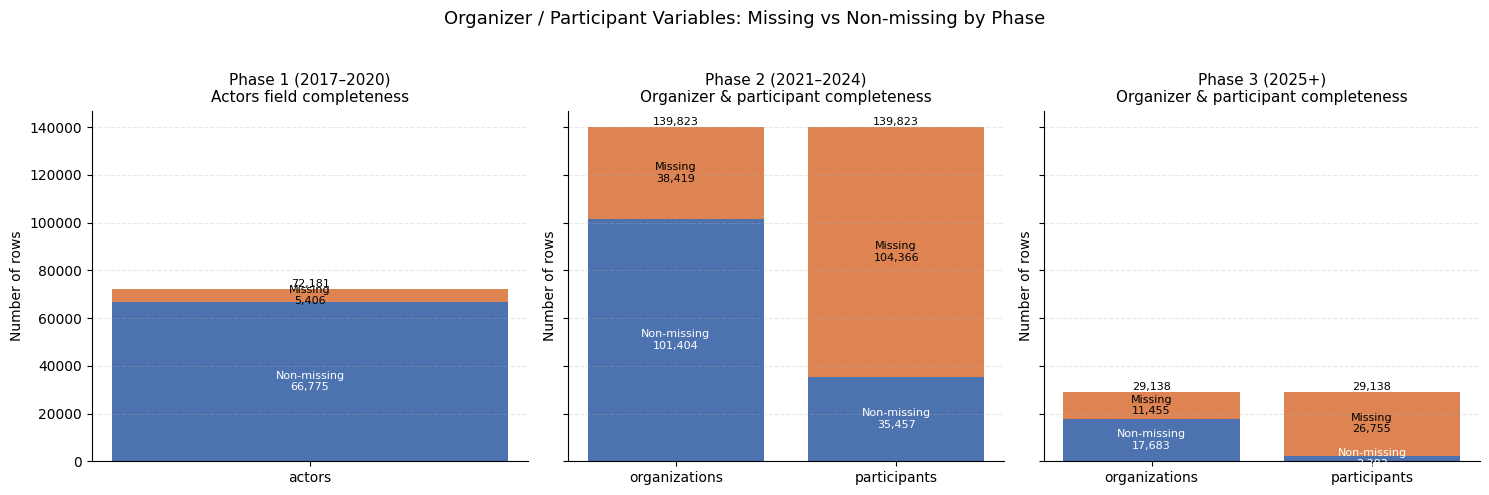

In [32]:
# -------------------------
# Helper functions
# -------------------------
def is_null(series: pd.Series) -> pd.Series:
    """Treat NaNs and empty/whitespace-only strings as null."""
    return series.isna() | (series.astype(str).str.strip() == "")

def null_nonnull_counts(df: pd.DataFrame, cols, labels=None):
    """
    For each column in cols, return (non_missing_count, missing_count).
    """
    if labels is None:
        labels = cols
    out = {}
    for col, label in zip(cols, labels):
        if col in df.columns:
            mask_null = is_null(df[col])
            missing = mask_null.sum()
            non_missing = len(df[col]) - missing
            out[label] = (non_missing, missing)
    return out

def plot_phase_stacked(ax, counts_dict, title):
    """
    counts_dict: {label: (non_missing, missing)}
    Makes a stacked bar on a provided axis: bottom=non-missing, top=missing.
    """
    labels = list(counts_dict.keys())
    non_missing = [counts_dict[l][0] for l in labels]
    missing = [counts_dict[l][1] for l in labels]
    x = np.arange(len(labels))

    # Modern-ish colors
    color_present = "#4C72B0"  # blue
    color_missing = "#DD8452"  # orange

    bars_present = ax.bar(x, non_missing, label="Non-missing", color=color_present)
    bars_missing = ax.bar(x, missing, bottom=non_missing, label="Missing", color=color_missing)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Number of rows")

    # Y-axis formatting
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    # Remove legend – we’ll label directly on bars
    # ax.legend(frameon=False)

    # Add labels on the bars
    for xi, nm, m in zip(x, non_missing, missing):
        total = nm + m

        # Label non-missing segment
        if nm > 0:
            ax.text(
                xi,
                nm / 2,
                f"Non-missing\n{nm:,}",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if nm > 0 else "black",
            )

        # Label missing segment
        if m > 0:
            ax.text(
                xi,
                nm + m / 2,
                f"Missing\n{m:,}",
                ha="center",
                va="center",
                fontsize=8,
                color="black",
            )

        # Optional: total on top
        ax.text(
            xi,
            total,
            f"{total:,}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

# -------------------------
# Compute counts per phase
# -------------------------

# Phase 1: actors only
counts_p1 = null_nonnull_counts(
    ccc_2017_2020,
    cols=["actors"],
    labels=["actors"]
)

# Phase 2: orgs & participants
counts_p2 = null_nonnull_counts(
    ccc_2021_2024,
    cols=["organizations", "participants"],
    labels=["organizations", "participants"]
)

# Phase 3: orgs & participants
counts_p3 = null_nonnull_counts(
    ccc_2025_plus,
    cols=["organizations", "participants"],
    labels=["organizations", "participants"]
)

# -------------------------
# Create 3 charts side by side
# -------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

plot_phase_stacked(
    axes[0],
    counts_p1,
    "Phase 1 (2017–2020)\nActors field completeness"
)

plot_phase_stacked(
    axes[1],
    counts_p2,
    "Phase 2 (2021–2024)\nOrganizer & participant completeness"
)

plot_phase_stacked(
    axes[2],
    counts_p3,
    "Phase 3 (2025+)\nOrganizer & participant completeness"
)

fig.suptitle("Organizer / Participant Variables: Missing vs Non-missing by Phase", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

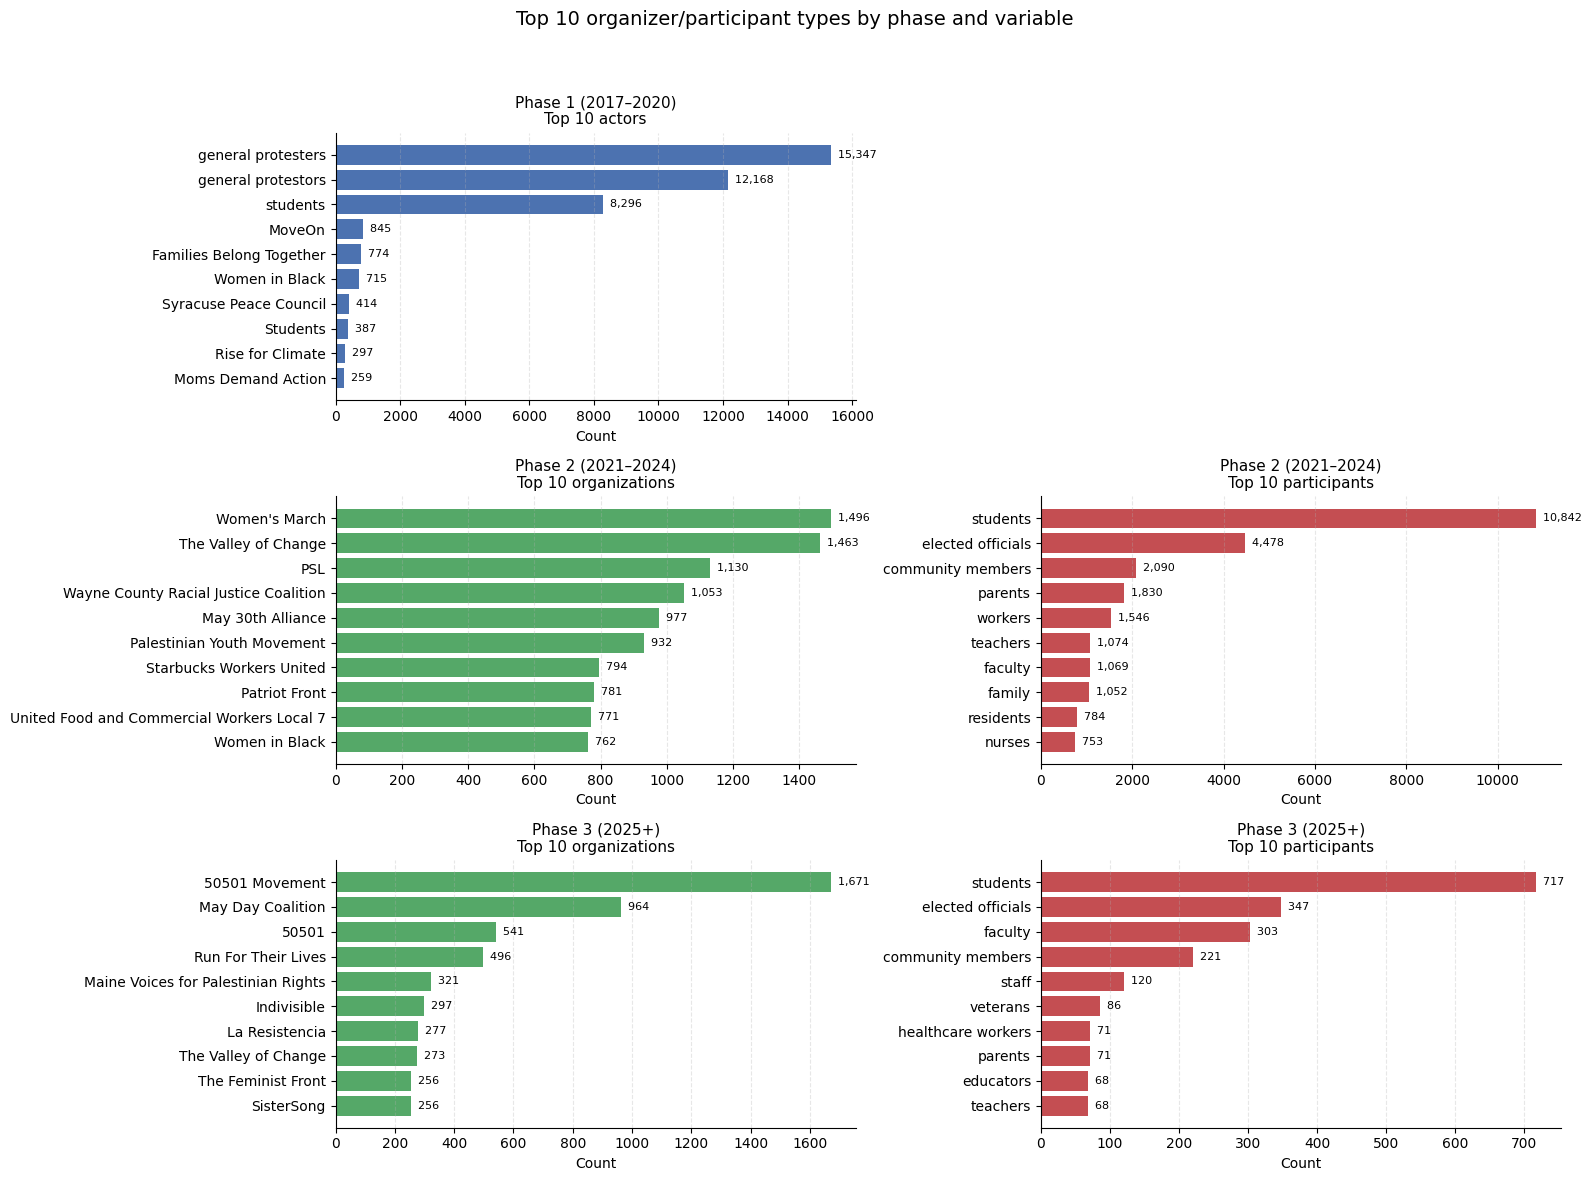

In [33]:

# ------------------------------------------------
# Helper: get top N tokens from one or more cols
# ------------------------------------------------
def get_top_tokens(df, cols, n=10):
    """
    For a list of columns, split on ';', strip whitespace,
    and return top n most frequent tokens.
    """
    counter = Counter()
    for col in cols:
        if col not in df.columns:
            continue
        series = df[col].dropna().astype(str)
        for val in series:
            val = val.strip()
            if not val:
                continue
            parts = [p.strip() for p in val.split(";")]
            for p in parts:
                if p:
                    counter[p] += 1

    if not counter:
        return pd.Series(dtype=int)
    return pd.Series(counter).sort_values(ascending=False).head(n)

# ------------------------------------------------
# 1) Compute top 10 for each phase/variable
# ------------------------------------------------
# Phase 1
top_p1_actors = get_top_tokens(ccc_2017_2020, ["actors"], n=10)

# Phase 2
top_p2_orgs  = get_top_tokens(ccc_2021_2024, ["organizations"], n=10)
top_p2_parts = get_top_tokens(ccc_2021_2024, ["participants"], n=10)

# Phase 3
top_p3_orgs  = get_top_tokens(ccc_2025_plus, ["organizations"], n=10)
top_p3_parts = get_top_tokens(ccc_2025_plus, ["participants"], n=10)

# ------------------------------------------------
# 2) Plot helper: modern horizontal bar chart
# ------------------------------------------------
def plot_hbar(ax, series, title, color):
    if series.empty:
        ax.set_title(title, fontsize=11)
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.axis("off")
        return

    y_pos = np.arange(len(series))
    ax.barh(y_pos, series.values, color=color)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(series.index)
    ax.invert_yaxis()  # highest at top
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Count")

    # add value labels at end of bars
    for i, v in enumerate(series.values):
        ax.text(v, i, f"  {v:,}", va="center", fontsize=8)

    # modern clean look
    ax.grid(axis="x", linestyle="--", alpha=0.3)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# ------------------------------------------------
# 3) Create 3 rows of charts
#    Row 1: Phase 1 (actors only, left; right axis off)
#    Row 2: Phase 2 (orgs, participants)
#    Row 3: Phase 3 (orgs, participants)
# ------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=False)

# color palette (modern-ish)
color_actors       = "#4C72B0"  # blue
color_organizations = "#55A868" # green
color_participants  = "#C44E52" # red-ish

# Row 1: Phase 1
plot_hbar(
    axes[0, 0],
    top_p1_actors,
    "Phase 1 (2017–2020)\nTop 10 actors",
    color_actors,
)
axes[0, 1].axis("off")  # no second chart for Phase 1

# Row 2: Phase 2
plot_hbar(
    axes[1, 0],
    top_p2_orgs,
    "Phase 2 (2021–2024)\nTop 10 organizations",
    color_organizations,
)
plot_hbar(
    axes[1, 1],
    top_p2_parts,
    "Phase 2 (2021–2024)\nTop 10 participants",
    color_participants,
)

# Row 3: Phase 3
plot_hbar(
    axes[2, 0],
    top_p3_orgs,
    "Phase 3 (2025+)\nTop 10 organizations",
    color_organizations,
)
plot_hbar(
    axes[2, 1],
    top_p3_parts,
    "Phase 3 (2025+)\nTop 10 participants",
    color_participants,
)

fig.suptitle("Top 10 organizer/participant types by phase and variable", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Claims (the `claims_all` concept)

Across phases, CCC records **what the event was about** – the issues, demands, and messages.

- **Phase 1 (2017–2020)**  
  - Column: `claims` – coder-written phrases summarizing what the event was about (semicolon-separated). 
- **Phase 2 (2021–2024)**  
  - Columns:  
    - `claims_summary` – concise coder summaries of the main claims.
    - `claims_verbatim` – verbatim phrases from signs, banners, chants, etc. 

- **Phase 3 (2025+)**  
  - Columns: `claims_summary` and `claims_verbatim`, defined as in Phase 2; no separate `claims` field.
    
### Conceptual summary

For analysis, you can treat:

- Phase 1: `claims`  
- Phase 2–3: `claims_summary` **+** `claims_verbatim`  

as one broader concept, **`claims_all`** = “all textual descriptions of what the protest was about.”


| Phase        | Column           | Example                                                                                                   |
|-------------|------------------|-----------------------------------------------------------------------------------------------------------|
| 2017–2020   | claims           | against demolition of house considered a historic landmark                                               |
| 2017–2020   | claims           | against verdict in child molestation case                                                                |
| 2017–2020   | claims           | anti-animal abuse                                                                                        |
| 2021–2024   | claims_summary   | for fair wages for employees of Applebee's restaurant;against racial discrimination and harassment       |
| 2021–2024   | claims_summary   | in support of Palestinian resistance;in solidarity with Jenin;against Israeli apartheid                  |
| 2021–2024   | claims_summary   | against increase in co-pay for medical visits and understaffed facilities and lack of adequate COVID-19 safety protocols |
| 2021–2024   | claims_verbatim  | celebrate your pride;love wins every time;2 4 6 8 we're queer stop the hate                              |
| 2021–2024   | claims_verbatim  | Temecula Voices Unheard Students Denied;claiming to not see race leads to inequity in our curriculum;let history be taught / walkout 3rd / let our voices be heard |
| 2021–2024   | claims_verbatim  | American flag;Israel flag                                                                                |
| 2025+       | claims_summary   | against President Trump's abuse of power; for democracy; against Arizona Senate Bill 1164 restricting access to abortion |
| 2025+       | claims_summary   | against Palantir; for Palestinian liberation                                                             |
| 2025+       | claims_summary   | against US Representative Derrick Van Orden support for President Trump's Big Beautiful Bill; against President Trump; against the Big Beautiful Bill |
| 2025+       | claims_verbatim  | don't develop the everglades; protect the everglades; save the glades no prison; no walls; #NoPrison…   |
| 2025+       | claims_verbatim  | mar-a-lago home of the whopper; dump DOGE; free Mohsen Mahdawi                                           |
| 2025+       | claims_verbatim  | hey hey! ho ho! the data centers have got to go!; Landover says no data center                           |


## Issues (the `issues` / `issue_tags` concept)

Across phases, CCC assigns **topical issue tags** to each event (e.g., policing, immigration, COVID). These tags are derived mainly from the claims fields.

- **Phase 1 (2017–2020)**  
  - Column: `issues`  
  - Meaning: semicolon-separated canonical issue tags for the event (e.g., `policing; racism`).  

- **Phase 2 (2021–2024)**  
  - Columns:  
    - `issue_tags` – the **union** of all issue tags detected for the event.  
    - `issue_tags_summary` – issue tags triggered by `claims_summary`.  
    - `issue_tags_verbatim` – issue tags triggered by `claims_verbatim`.  

- **Phase 3 (2025+)**  
  - Columns:  
    - `issues` – the union of all issue tags for the event (same role as `issue_tags` in Phase 2).  
    - `issue_tags_summary` – tags from `claims_summary`.  
    - `issue_tags_verbatim` – tags from `claims_verbatim`.  

### Conceptual summary

For analysis, we can treat:

- Phase 1: `issues`  
- Phase 2: `issue_tags` (optionally alongside `issue_tags_summary` / `issue_tags_verbatim`)  
- Phase 3: `issues` (optionally alongside `issue_tags_summary` / `issue_tags_verbatim`)  

as one broader concept: **“which political issues this protest is about.”**


## Issues: example values

A few example values from the issues / issue_tags fields:

| Phase        | Column                | Example value                                                                     |
|-------------|------------------------|-----------------------------------------------------------------------------------|
| 2017–2020   | `issues`              | `military`                                                                        |
| 2017–2020   | `issues`              | `environment; guns; military`                                                     |
| 2017–2020   | `issues`              | `education; racism`                                                               |
| 2021–2024   | `issue_tags`          | `covid;criminal justice;labor`                                                   |
| 2021–2024   | `issue_tags`          | `foreign affairs`                                                                 |
| 2021–2024   | `issue_tags`          | `banking and finance;covid;economy;housing`                                      |
| 2021–2024   | `issue_tags_summary`  | `covid; democracy; presidency`                                                    |
| 2021–2024   | `issue_tags_summary`  | `banking and finance; covid; economy; housing`                                   |
| 2021–2024   | `issue_tags_verbatim` | `policing; racism`                                                                |
| 2021–2024   | `issue_tags_verbatim` | `indigenous peoples`                                                              |
| 2025+       | `issues`              | `policing;war and peace`                                                         |
| 2025+       | `issues`              | `corruption;policing;racism;war and peace`                                       |
| 2025+       | `issue_tags_summary`  | `economy; foreign affairs; war and peace`                                        |
| 2025+       | `issue_tags_summary`  | `criminal justice; foreign affairs; war and peace; policing; racism`             |
| 2025+       | `issue_tags_verbatim` | `foreign affairs; war and peace; policing`                                       |
| 2025+       | `issue_tags_verbatim` | `civil rights; foreign affairs; free speech; healthcare; war and peace`          |

These examples illustrate how each field encodes **one or more issue tags** using semicolon-separated canonical categories.


In [34]:
# Markdown header for your notebook
display(Markdown("## How many unique tags do we have for each variable?"))

# Helper: get unique semicolon-separated values from a column
def get_unique_tokens(df, col):
    if col not in df.columns:
        return set()
    vals = df[col].dropna().astype(str)
    uniques = set()
    for v in vals:
        parts = [p.strip() for p in v.split(";")]
        for p in parts:
            if p:
                uniques.add(p)
    return uniques

# Define which columns belong to the "issues" concept
issue_columns = [
    ("2017–2020", "issues",              ccc_2017_2020, "issues"),
    ("2021–2024", "issue_tags",          ccc_2021_2024, "issue_tags"),
    ("2021–2024", "issue_tags_summary",  ccc_2021_2024, "issue_tags_summary"),
    ("2021–2024", "issue_tags_verbatim", ccc_2021_2024, "issue_tags_verbatim"),
    ("2025+",     "issues",              ccc_2025_plus, "issues"),
    ("2025+",     "issue_tags_summary",  ccc_2025_plus, "issue_tags_summary"),
    ("2025+",     "issue_tags_verbatim", ccc_2025_plus, "issue_tags_verbatim"),
]

results = []
unique_dict = {}  # to inspect actual tags later if you want

for phase_label, col_label, df, col_name in issue_columns:
    tags = get_unique_tokens(df, col_name)
    unique_dict[(phase_label, col_label)] = tags
    results.append(
        {"Phase": phase_label, "Column": col_label, "# unique issue tags": len(tags)}
    )

summary_df = pd.DataFrame(results)
display(summary_df)

## How many unique tags do we have for each variable?

,Phase,Column,# unique issue tags
0,2017–2020,issues,38
1,2021–2024,issue_tags,38
2,2021–2024,issue_tags_summary,38
3,2021–2024,issue_tags_verbatim,38
4,2025+,issues,38
5,2025+,issue_tags_summary,38
6,2025+,issue_tags_verbatim,38


## Participant injuries and casualties

Across phases, CCC records **harm to protest participants** – whether anyone was injured or killed, and sometimes how many.

- **Phase 1 (2017–2020)**  
  - `injuries_crowd` – text/number describing how many protesters were reportedly injured (or phrases like “unspecified”).  
  - `injuries_crowd_any` – binary flag for whether any protesters were reportedly injured (1 = yes, 0 = no).  

- **Phase 2 (2021–2024)**  
  - `injuries_crowd` – as in Phase 1, a text/number field for participant injuries.  
  - `injuries_crowd_any` – binary flag for any reported participant injuries.  
  - `participant_deaths` – reported count (or phrase) for protest participants who died in connection with the event.  

- **Phase 3 (2025+)**  
  - `participant_injuries` – text/number describing how many participants were reportedly injured.  
  - `participant_deaths` – reported count (or phrase) for participant deaths.  
  - `participant_casualties_any` – binary flag for whether **any participants were harmed** (injured or killed) during the event.  

### Conceptual summary

For a unified **participant harm / casualties** concept you can treat:

- Phase 1–2: `injuries_crowd` (+ `injuries_crowd_any`) and, where available, `participant_deaths`  
- Phase 3: `participant_injuries`, `participant_deaths`, and `participant_casualties_any`  

as different implementations of the same idea: **whether and how severely protesters were physically harmed at an event.**


### Phase 1 (2017–2020) — top 10 values for `injuries_crowd`

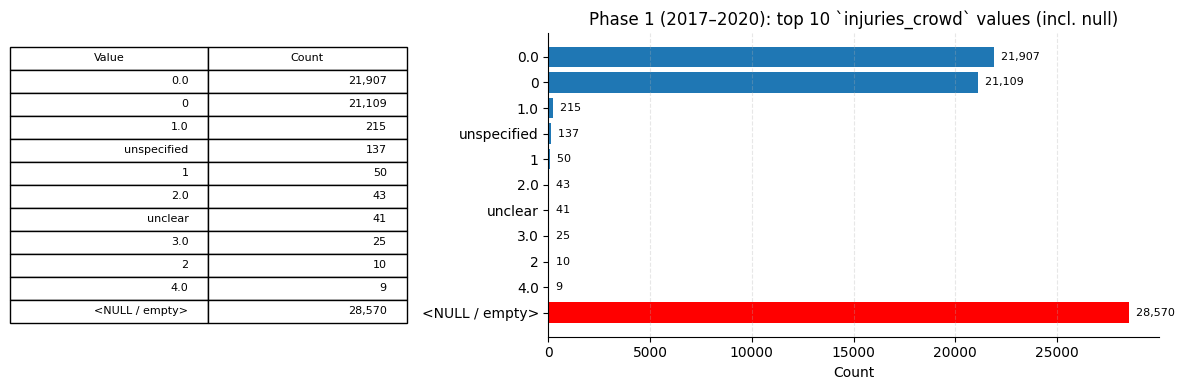

### Phase 2 (2021–2024) — top 10 values for `injuries_crowd`

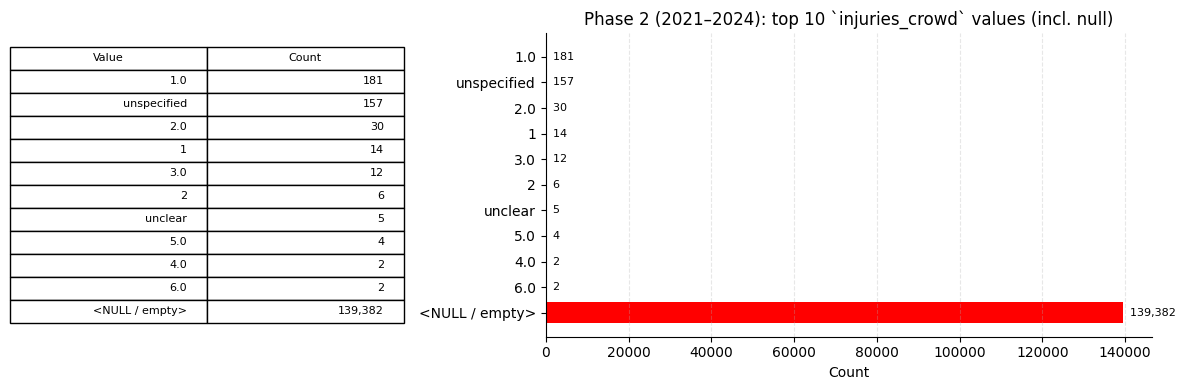

### Phase 2 (2021–2024) — top 10 values for `participant_deaths`

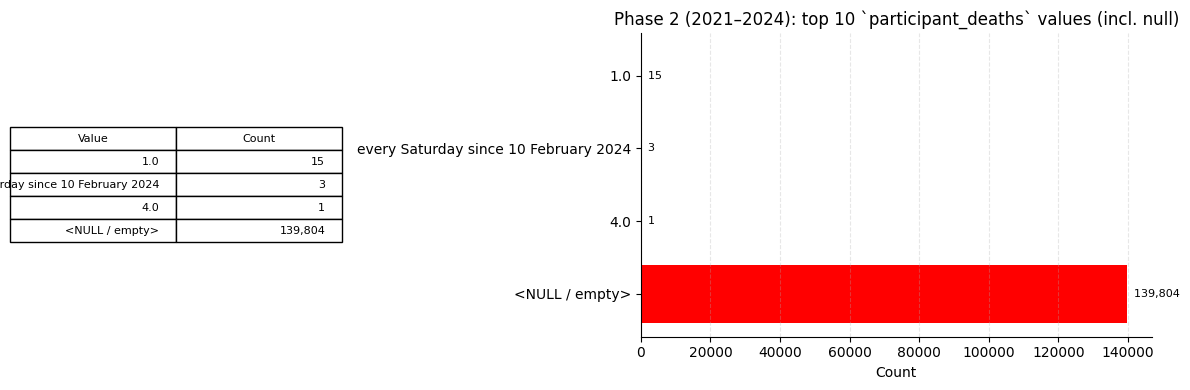

### Phase 3 (2025+) — top 10 values for `participant_injuries`

/tmp/ipykernel_17240/600418419.py:86: UserWarning:

Glyph 128 (\x80) missing from font(s) DejaVu Sans.

/tmp/ipykernel_17240/600418419.py:86: UserWarning:

Glyph 153 (\x99) missing from font(s) DejaVu Sans.

/home/ameyagurjar/thesis/thesis_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 128 (\x80) missing from font(s) DejaVu Sans.

/home/ameyagurjar/thesis/thesis_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning:

Glyph 153 (\x99) missing from font(s) DejaVu Sans.



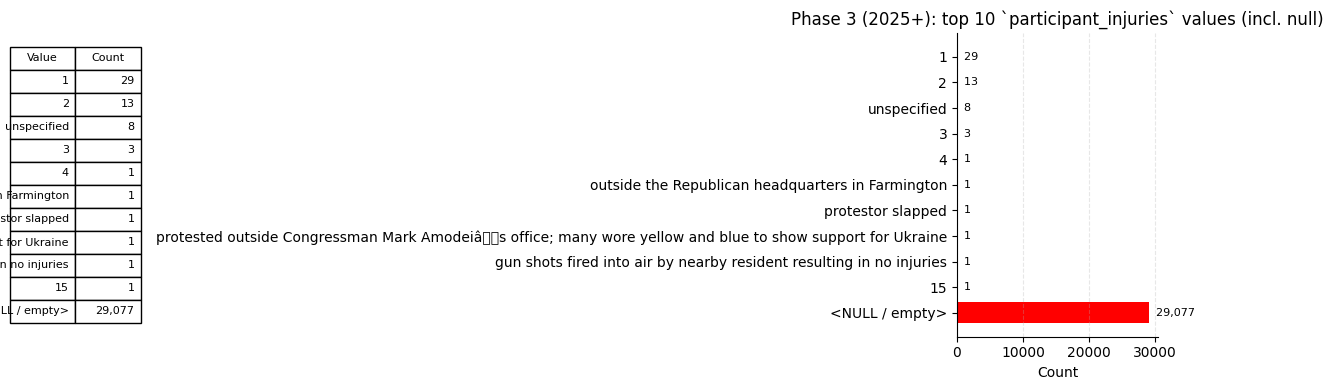

### Phase 3 (2025+) — top 10 values for `participant_deaths`

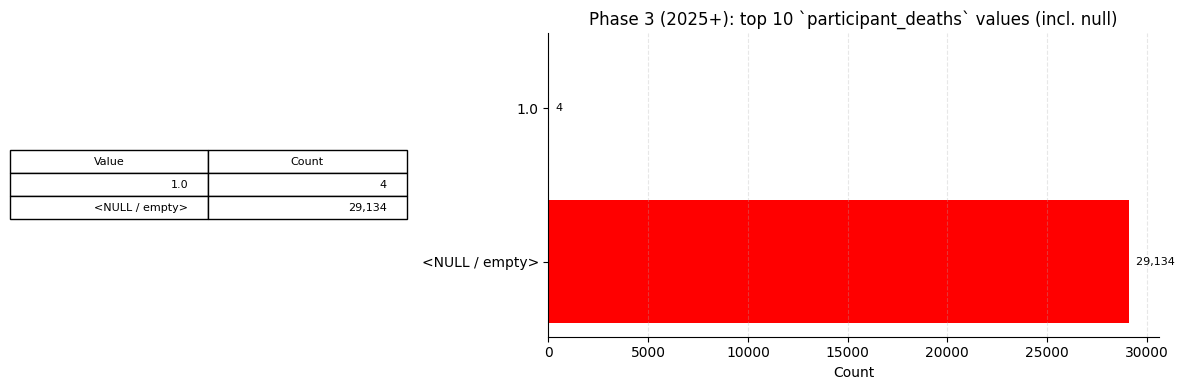

In [35]:
# -----------------------------
# Helpers for top-10 text values
# -----------------------------
def get_top_10_text_and_null(df, col):
    """Return top-10 value_counts (excluding null/empty) and the total null/empty count."""
    if col not in df.columns:
        return pd.Series(dtype=int), 0
    
    raw = df[col]
    # null if NaN or empty/whitespace-only or literal "nan"
    is_null = raw.isna() | (raw.astype(str).str.strip() == "") | (
        raw.astype(str).str.strip().str.lower() == "nan"
    )
    null_count = is_null.sum()
    
    s = raw[~is_null].astype(str).str.strip()
    vc = s.value_counts().head(10)
    return vc, null_count

def show_top_10_with_table_and_plot(df, col, phase_label):
    """Show top-10 table and horizontal bar chart side by side, including null count."""
    vc, null_count = get_top_10_text_and_null(df, col)
    if vc.empty and null_count == 0:
        display(Markdown(f"### {phase_label} — `{col}` (no data)"))
        return
    
    display(Markdown(f"### {phase_label} — top 10 values for `{col}`"))
    
    # -------- Figure layout: table | bar chart --------
    fig, (ax_table, ax_bar) = plt.subplots(
        1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.3, 2.0]}
    )

    # ----- Left: table -----
    ax_table.axis("off")
    table_rows = [[idx, f"{val:,}"] for idx, val in vc.items()]
    # add null/empty row
    table_rows.append(["<NULL / empty>", f"{null_count:,}"])
    
    tbl = ax_table.table(
        cellText=table_rows,
        colLabels=["Value", "Count"],
        loc="center"
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    tbl.scale(1, 1.4)

    # ----- Right: horizontal bar chart -----
    # non-null bars
    labels_nonnull = list(vc.index)
    counts_nonnull = list(vc.values)
    n_nonnull = len(labels_nonnull)
    
    # y positions: 0..n_nonnull-1 for non-null, n_nonnull for null
    y_nonnull = np.arange(n_nonnull)
    y_null = n_nonnull
    
    # plot non-null bars (default color)
    ax_bar.barh(y_nonnull, counts_nonnull)
    
    # plot null bar in bright red
    ax_bar.barh([y_null], [null_count], color="red")
    
    # all labels including null
    all_labels = labels_nonnull + ["<NULL / empty>"]
    all_y = np.append(y_nonnull, y_null)
    all_counts = counts_nonnull + [null_count]
    
    ax_bar.set_yticks(all_y)
    ax_bar.set_yticklabels(all_labels)
    ax_bar.invert_yaxis()
    
    ax_bar.set_xlabel("Count")
    ax_bar.set_title(f"{phase_label}: top 10 `{col}` values (incl. null)")

    # Modern styling
    ax_bar.grid(axis="x", linestyle="--", alpha=0.3)
    for spine in ["top", "right"]:
        ax_bar.spines[spine].set_visible(False)

    # Add count labels at bar ends
    for y, v in zip(all_y, all_counts):
        ax_bar.text(v, y, f"  {v:,}", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

# -----------------------------
# Top 10 free-text values (table + plot side by side)
# -----------------------------
# Phase 1: injuries_crowd
show_top_10_with_table_and_plot(ccc_2017_2020, "injuries_crowd", "Phase 1 (2017–2020)")

# Phase 2: injuries_crowd, participant_deaths
show_top_10_with_table_and_plot(ccc_2021_2024, "injuries_crowd", "Phase 2 (2021–2024)")
show_top_10_with_table_and_plot(ccc_2021_2024, "participant_deaths", "Phase 2 (2021–2024)")

# Phase 3: participant_injuries, participant_deaths
show_top_10_with_table_and_plot(ccc_2025_plus, "participant_injuries", "Phase 3 (2025+)")
show_top_10_with_table_and_plot(ccc_2025_plus, "participant_deaths", "Phase 3 (2025+)")

## Police injuries and casualties

Across phases, CCC records **harm to police officers** in connection with protest events.

- **Phase 1 (2017–2020)**  
  - `injuries_police` – text/number describing how many police were reportedly injured (or phrases like “unspecified”).  
  - `injuries_police_any` – binary flag for whether any police were reportedly injured (1 = yes, 0 = no).  

- **Phase 2 (2021–2024)**  
  - `injuries_police` – text/number for police injuries.  
  - `injuries_police_any` – binary flag for any reported police injuries.  
  - `police_deaths` – reported count (or phrase) for police deaths connected to the event.  

- **Phase 3 (2025+)**  
  - `police_injuries` – text/number describing how many police were reportedly injured.  
  - `police_deaths` – reported count (or phrase) for police deaths.  
  - `police_casualties_any` – binary flag for whether **any police were harmed** (injured or killed) during the event.  

### Conceptual summary

For a unified **police harm / casualties** concept you can treat:

- Phase 1–2: `injuries_police` (+ `injuries_police_any`) and, where available, `police_deaths`  
- Phase 3: `police_injuries`, `police_deaths`, and `police_casualties_any`  

as different implementations of the same idea: **whether and how severely police were physically harmed at an event.**


### Phase 1 (2017–2020) — top 10 values for `injuries_police`

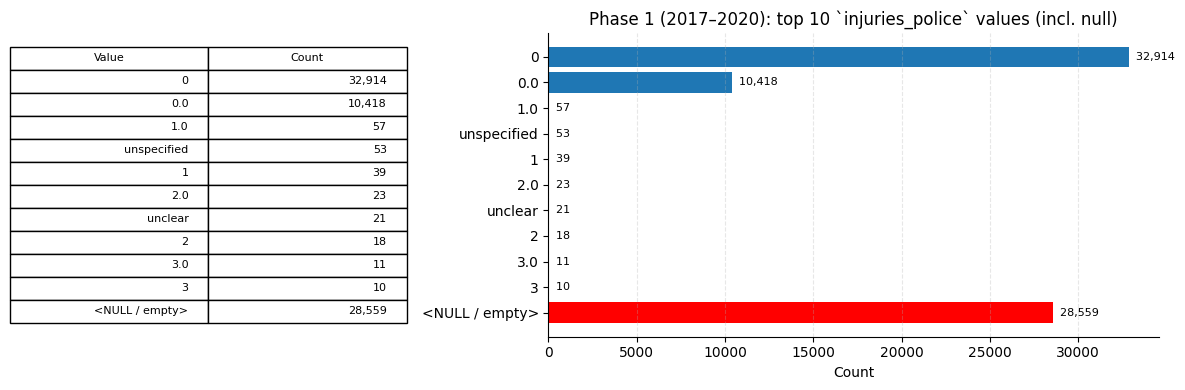

### Phase 2 (2021–2024) — top 10 values for `injuries_police`

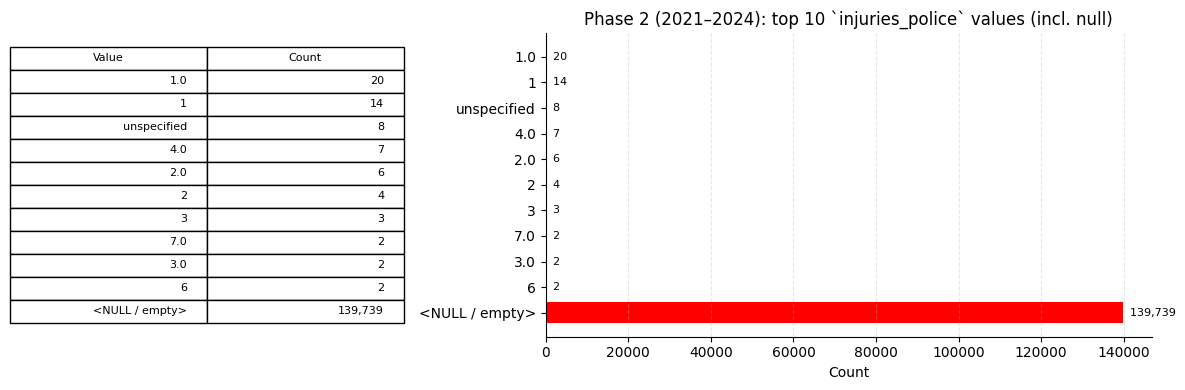

### Phase 2 (2021–2024) — top 10 values for `police_deaths`

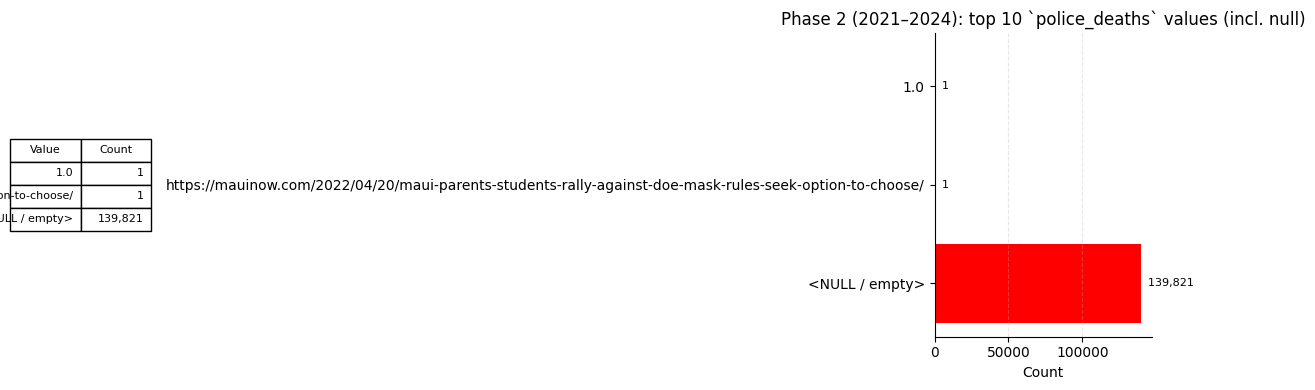

### Phase 3 (2025+) — top 10 values for `police_injuries`

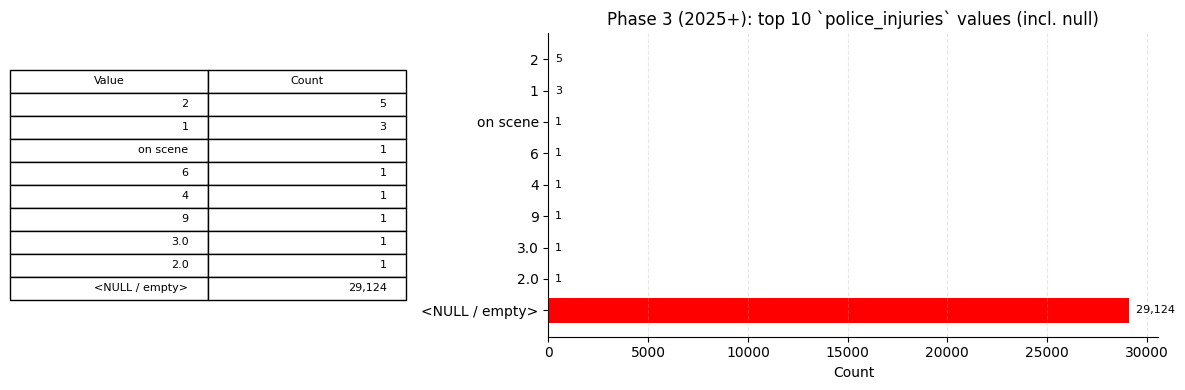

### Phase 3 (2025+) — top 10 values for `police_deaths`

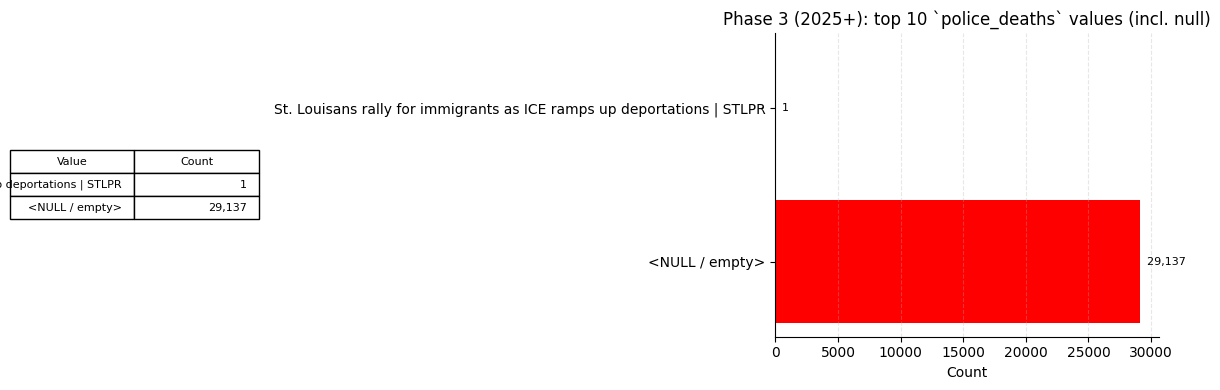

In [36]:
# -----------------------------
# Top 10 free-text values for POLICE harm
# (table + plot side by side, incl. null bar)
# -----------------------------

# Phase 1: police injuries
show_top_10_with_table_and_plot(
    ccc_2017_2020,
    "injuries_police",
    "Phase 1 (2017–2020)"
)

# Phase 2: police injuries and deaths
show_top_10_with_table_and_plot(
    ccc_2021_2024,
    "injuries_police",
    "Phase 2 (2021–2024)"
)
show_top_10_with_table_and_plot(
    ccc_2021_2024,
    "police_deaths",
    "Phase 2 (2021–2024)"
)

# Phase 3: police injuries and deaths
show_top_10_with_table_and_plot(
    ccc_2025_plus,
    "police_injuries",
    "Phase 3 (2025+)"
)
show_top_10_with_table_and_plot(
    ccc_2025_plus,
    "police_deaths",
    "Phase 3 (2025+)"
)


## Chemical agents

Across phases, CCC tracks whether **chemical agents** (e.g., tear gas, pepper spray, CS gas) were reportedly used at an event.

- **Phase 1 (2017–2020)**  
  - Column: `chemical_agents`  
  - Meaning: free-text indicator of chemical-agent use, typically noting whether tear gas, pepper spray, or similar agents were deployed, and sometimes by whom (e.g., police, security).

- **Phase 2 (2021–2024)**  
  - Column: `chemical_agents`  
  - Meaning: same role as in Phase 1, recording reported use of chemical agents during the event (including “none” / “no” language in some entries).

- **Phase 3 (2025+)**  
  - No dedicated `chemical_agents` column.  
  - Chemical-agent use, if reported, is instead described in narrative fields such as `police_measures` and `participant_measures` (e.g., “police used tear gas to disperse crowd”).

### Conceptual summary

For analysis, you can treat:

- Phase 1–2: `chemical_agents`  
- Phase 3: references to tear gas / pepper spray / other agents in `police_measures` (and occasionally `participant_measures`)  

as different implementations of the same concept: **whether chemical crowd-control agents were used at the protest.**


## Additional variables that differ across phases

- **participant_deaths**  
  Count or description of protester deaths linked to the event.  
  Present in Phases 2–3; complements injuries fields for participant harm.

- **participant_measures**  
  Free-text description of what protesters did (tactics, behaviors, escalation).  
  Present in Phases 2–3; often includes things like marches, blockades, sit-ins.

- **police_deaths**  
  Count or description of police deaths linked to the event.  
  Present in Phases 2–3; complements injuries fields for police harm.

- **police_measures**  
  Free-text description of what police did (presence, crowd control, arrests, force).  
  Present in Phases 2–3; where use of force and chemical agents are typically noted.

- **title**  
  Short, human-readable label for the event (e.g., “Teachers’ strike at City Hall”).  
  Present in Phase 2; useful for quick browsing and qualitative work.

- **conf**  
  Coder confidence score in the accuracy/completeness of the record.  
  Present in Phase 3; helps weight or filter events by coding certainty.

- **notables**  
  Named high-profile individuals who participated (e.g., elected officials, celebrities).  
  Present in Phase 3; distinguishes prominent attendees from general participants.

- **targets**  
  Specific institutions/people the event is directed at (e.g., “City Council”, “ICE”).  
  Present in Phase 3; makes it easier to analyze who protests are aimed at.
